# Predicting 30-Day Hospital Readmission for Diabetic Patients

**ML for Social Good Ensemble Challenge — CIA 3**
MCA 521-4 Machine Learning · CHRIST (Deemed to be University)

**Mission: Health.** Predict which diabetic inpatients will be readmitted within
30 days, so that a clinic with limited follow-up capacity calls the right people.

---

### How to read this notebook

Every step follows the same shape: what we do and why, then the code, then a
figure, then what the figure actually shows. Sections close with an inference —
the decision the evidence forced.

| Section | Rubric question | Marks |
|---|---|---|
| 1. Problem framing | Q1 Real-World Impact Framing | 5 |
| 2. Data audit and cleaning | Q2 Data Wrangling | 6 |
| 3. Exploratory analysis | Q2 (EDA) | — |
| 4. Feature engineering and pipeline | Q2 (features, leakage) | — |
| 5. Baselines, bagging, boosting | Q3 Ensemble Architecture | 8 |
| 6. Stacking, voting, final comparison | Q3 (comparison) | — |
| 7. Explainability | Q4 Explainability and Ethics | 4 |
| 8. Fairness and ethics | Q4 | — |

Reproduce everything headless with `python -m src.train`.

In [1]:
import json, warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

from src import config as C
from src import evaluate as E
from src import viz

viz.set_style()

print(f"Seed: {C.SEED}")
print(f"Python {sys.version.split()[0]}")
for m in ["numpy", "pandas", "sklearn", "xgboost", "lightgbm", "shap"]:
    mod = __import__(m)
    print(f"  {m:10s} {getattr(mod, '__version__', '?')}")

Seed: 42
Python 3.13.5
  numpy      2.5.2
  pandas     2.3.3
  sklearn    1.9.0
  xgboost    3.4.0
  lightgbm   4.7.0


  shap       0.52.0


---
## 1 · Real-World Impact Framing

### The problem
- Roughly 1 in 9 diabetic inpatients returns to hospital within 30 days.
- Each avoidable readmission costs a health system on the order of **$15,000**.
- In the US, CMS financially penalises hospitals with excess readmission rates.
- A follow-up call within a week measurably reduces that risk.
- Under-resourced clinics cannot call everyone. They must choose.

### Who benefits
- **Patients**, especially uninsured and high-utilising ones, who get a call instead of a relapse.
- **Discharge nurses**, who receive a ranked worklist instead of an undifferentiated ward list.
- **Safety-net hospitals**, which carry fixed follow-up capacity and rising penalties.

### What we predict
- **Target:** probability of readmission within 30 days of discharge.
- **Type:** binary classification; positive class ≈ 9% after cleaning.
- **Decision point:** at discharge, using only what is known at that moment.

### How impact is measured
- Not accuracy. With a 9% base rate, predicting "no" for everyone scores 91%.
- **Precision@10%** — of the patients we call, how many would truly have returned.
- **Lift@10%** — how many times better than calling patients at random.
- Converted to readmissions averted per 1,000 discharges.

### Why machine learning is the right tool
- 47 heterogeneous fields interact non-linearly: prior utilisation × comorbidity × glycaemic testing.
- Published logistic models on this data plateau around AUC 0.63–0.68, so there is measurable headroom for ensembles.
- Volume makes manual triage impossible; ranking is exactly what a model does well.
- A rule of thumb ("anyone over 65 with 2+ prior visits") is a model with worse calibration and no uncertainty estimate.

### Responsible-use limits
- Data is US, 1999–2008. Stale for deployment without refitting.
- **Triage aid only.** Never care denial, insurance pricing, or a discharge decision.
- Out-of-network readmissions are invisible in this data, so labels undercount mobile and uninsured patients.
- Full statement in [`docs/ETHICS.md`](../docs/ETHICS.md).

### Why this dataset
See [`docs/DATASET_CARD.md`](../docs/DATASET_CARD.md) for the full comparison. Short version: it is
peer-reviewed at source, and it is one of very few public health datasets that genuinely contains
every wrangling problem this assessment asks us to handle.

In [2]:
from src.data_loader import load_raw_typed

raw = load_raw_typed()

print(f"Dataset : {C.DATASET_NAME}")
print(f"Source  : {C.DATASET_UCI_PAGE}")
print(f"Licence : {C.DATASET_LICENCE}")
print(f"Citation: {C.CITATION}\n")
print(f"Shape           : {raw.shape[0]:,} encounters x {raw.shape[1]} columns")
print(f"Unique patients : {raw['patient_nbr'].nunique():,}")
print(f"Hospitals       : 130 US hospitals and delivery networks, 1999-2008\n")

target_dist = raw[C.RAW_TARGET].value_counts(normalize=True).mul(100).round(2)
print("Raw target distribution (%):")
print(target_dist.to_string())

Dataset : Diabetes 130-US Hospitals for Years 1999-2008
Source  : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
Licence : CC BY 4.0
Citation: Strack, B., DeShazo, J. P., Gennings, C., Olmo, J. L., Ventura, S., Cios, K. J., & Clore, J. N. (2014). Impact of HbA1c measurement on hospital readmission rates: Analysis of 70,000 clinical database patient records. BioMed Research International, 2014, 781670. https://doi.org/10.1155/2014/781670

Shape           : 101,766 encounters x 50 columns
Unique patients : 71,518
Hospitals       : 130 US hospitals and delivery networks, 1999-2008

Raw target distribution (%):
readmitted
NO     53.91
>30    34.93
<30    11.16


**Observations**

- 101,766 encounters but only 71,518 patients: rows are *not* independent observations.
- `<30` (our positive class) is 11.16% of raw encounters.
- `>30` at 34.93% is folded into the negative class — a readmission at day 200 is a different
  clinical phenomenon with different drivers, and it carries no CMS penalty.
- The unit of analysis question is therefore live from the first line: encounter or patient?

---
## 2 · Data Audit and Cleaning

Every decision below is recorded with a reason. The full logic is in
[`src/cleaning.py`](../src/cleaning.py) so it is reproducible rather than clicked through once.

### Step 2.1 · Missingness audit

**What we do**
- Convert the `?` sentinel to proper `NaN`.
- Measure missingness per column.
- Test whether missingness is related to the outcome.

**Why**
- `?` read as a string silently becomes a valid category.
- Columns missing at 97% and 2% need opposite treatments.
- If missingness predicts the target it is *informative*, and deleting it destroys signal.

Missing values by column (%):
weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02


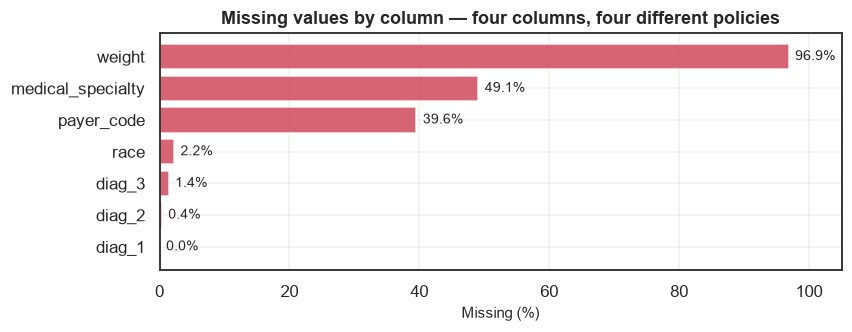

In [3]:
missing = (raw.isna().mean() * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column (%):")
print(missing.to_string())

viz.plot_missingness(raw);

,column,pct_missing,readmit_rate_when_recorded,readmit_rate_when_missing,difference
0,weight,96.86,0.1117,0.1116,-0.0001
1,medical_specialty,49.08,0.1076,0.1157,0.0081
2,payer_code,39.56,0.1094,0.1149,0.0055
3,race,2.23,0.1123,0.0827,-0.0296


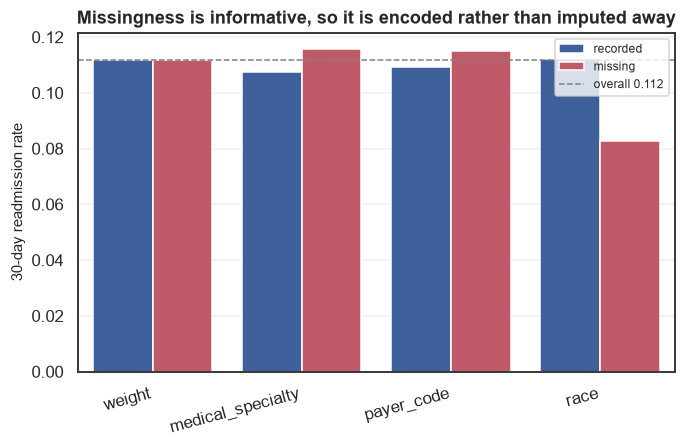

In [4]:
# Is the missingness random, or does it carry information about the outcome?
tmp = raw.copy()
tmp[C.TARGET] = (tmp[C.RAW_TARGET] == "<30").astype(int)

rows = []
for col in ["weight", "medical_specialty", "payer_code", "race"]:
    flag = tmp[col].isna()
    rows.append({
        "column": col,
        "pct_missing": round(100 * flag.mean(), 2),
        "readmit_rate_when_recorded": round(tmp.loc[~flag, C.TARGET].mean(), 4),
        "readmit_rate_when_missing": round(tmp.loc[flag, C.TARGET].mean(), 4),
    })
mnar = pd.DataFrame(rows)
mnar["difference"] = (mnar["readmit_rate_when_missing"]
                      - mnar["readmit_rate_when_recorded"]).round(4)
display(mnar)

viz.plot_missingness_vs_target(tmp, ["weight", "medical_specialty", "payer_code", "race"]);

**Observations**

- `weight` is missing for **96.9%** of encounters. There is nothing to impute from.
- `medical_specialty` (49.1%) and `payer_code` (39.6%) are missing at rates too high to ignore
  and too structured to be random.
- Readmission rates differ between the recorded and missing groups in every case, so this is
  **not** missing-completely-at-random.
- `payer_code` missing skews toward self-pay and uninsured patients — exactly the population
  this project is meant to serve.
- `race` is missing for only 2.2%.

**Decisions taken**

| Column | Policy | Reason |
|---|---|---|
| `weight` | Drop the column, keep `weight_recorded` flag | Values unrecoverable, but *being weighed* proxies for care thoroughness |
| `medical_specialty` | Explicit `Unknown` level | Missingness is informative, not noise |
| `payer_code` | Explicit `Unknown` level + `payer_unknown` flag | Proxy for uninsured status; needed by the fairness audit |
| `race` | Explicit `Unknown` level, **never imputed** | Imputing a protected attribute fabricates the evidence the fairness audit exists to test |
| `diag_1/2/3` | Routed to an `Other` diagnosis group | Under 1.5% missing, and the ICD-9 grouping absorbs it cleanly |

### Step 2.2 · Duplicates and the leakage trap

**What we do**
- Check for exact duplicate rows.
- Count encounters per patient.
- Keep each patient's first encounter only.

**Why**
- 101,766 rows come from 71,518 people; a patient appearing in both train and test leaks.
- Frequent flyers (up to 40 encounters) would otherwise dominate training.
- Strack et al. resolved this the same way, so we stay comparable to the published result.

Exact duplicate rows      : 0
Duplicate encounter_id    : 0
Patients with >1 encounter: 16,773
Most encounters by one patient: 40


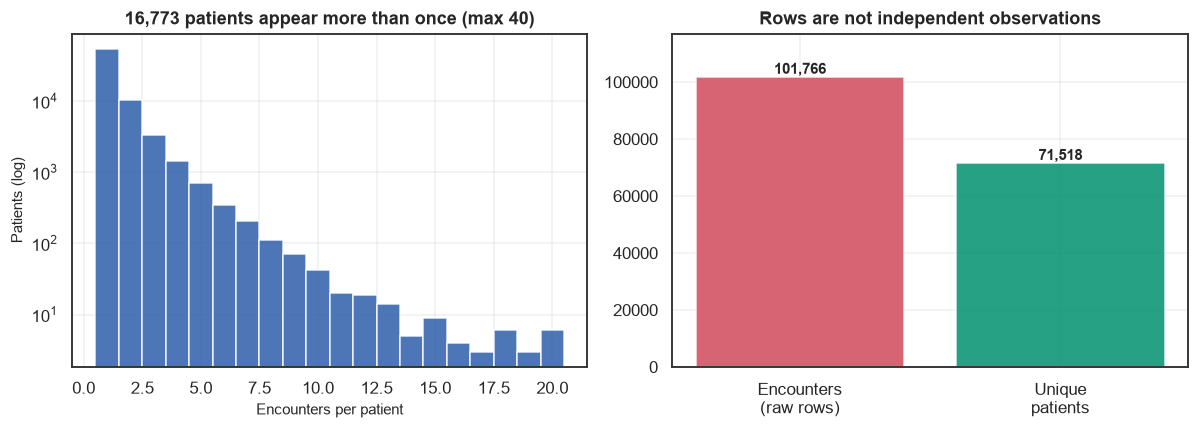

In [5]:
print(f"Exact duplicate rows      : {raw.duplicated().sum()}")
print(f"Duplicate encounter_id    : {raw['encounter_id'].duplicated().sum()}")

counts = raw["patient_nbr"].value_counts()
print(f"Patients with >1 encounter: {(counts > 1).sum():,}")
print(f"Most encounters by one patient: {counts.max()}")

viz.plot_encounters_per_patient(raw);

**Observations**

- Zero exact duplicate rows and zero duplicate `encounter_id`: the file is clean at row level.
- The duplication is at **patient** level — 16,773 patients appear more than once.
- One patient appears **40 times**.
- A random row split would place the same person in train and test, and the model would be
  scored partly on its ability to recall someone it had already met.

### Step 2.3 · Invalid and clinically impossible records

**What we do**
- Drop encounters ending in death or hospice transfer.
- Drop the 3 rows with `gender = 'Unknown/Invalid'`.

**Why**
- A patient who died cannot be readmitted, so their label is 0 for a reason unrelated to risk.
- Keeping them teaches the model that terminal illness predicts *safety* — an actively dangerous
  inversion.
- The exclusion list follows Strack et al. (2014) rather than our own judgement.

In [6]:
from src.data_loader import load_id_mappings

maps = load_id_mappings()
dd = raw["discharge_disposition_id"].value_counts()
excl = pd.DataFrame({
    "code": C.EXPIRED_OR_HOSPICE_DISCHARGE_IDS,
    "meaning": [maps["discharge_disposition_id"].get(c, "?")
                for c in C.EXPIRED_OR_HOSPICE_DISCHARGE_IDS],
    "rows": [int(dd.get(c, 0)) for c in C.EXPIRED_OR_HOSPICE_DISCHARGE_IDS],
})
display(excl)
print(f"Total excluded: {excl['rows'].sum():,} rows "
      f"({100 * excl['rows'].sum() / len(raw):.2f}%)")
print(f"\nGender values: {dict(raw['gender'].value_counts())}")

,code,meaning,rows
0,11,Expired,1642
1,13,Hospice / home,399
2,14,Hospice / medical facility,372
3,19,"Expired at home. Medicaid only, hospice.",8
4,20,"Expired in a medical facility. Medicaid only, ...",2
5,21,"Expired, place unknown. Medicaid only, hospice.",0


Total excluded: 2,423 rows (2.38%)

Gender values: {'Female': np.int64(54708), 'Male': np.int64(47055), 'Unknown/Invalid': np.int64(3)}


### Step 2.4 · Running the full cleaning pipeline

In [7]:
from src.cleaning import clean

clean_df, audit = clean()
display(audit.to_frame())

print(f"\nFinal: {len(clean_df):,} patients x {clean_df.shape[1]} columns")
print(f"Positive rate: {clean_df[C.TARGET].mean():.4f}")
print(f"One row per patient: {clean_df['patient_nbr'].is_unique}")
print("\nColumns dropped:")
for col, why in audit.dropped_columns.items():
    print(f"  - {col}: {why}")

,step,rows_before,rows_after,rows_dropped,pct_dropped,reason
0,raw,101766,101766,0,0.00,as downloaded from UCI
1,drop_expired_hospice,101766,99343,2423,2.38,"discharge_disposition_id in [11, 13, 14, 19, 2..."
2,drop_invalid_gender,99343,99340,3,0.00,gender='Unknown/Invalid' is a data-entry error...
3,deduplicate_patients,99340,69987,29353,29.55,keep first encounter per patient_nbr; later en...



Final: 69,987 patients x 53 columns
Positive rate: 0.0898
One row per patient: True

Columns dropped:
  - weight: 96.9% missing; replaced by weight_recorded indicator (missingness is informative, the values are not recoverable)
  - examide: single observed value; carries no information
  - citoglipton: single observed value; carries no information
  - glimepiride-pioglitazone: single observed value; carries no information


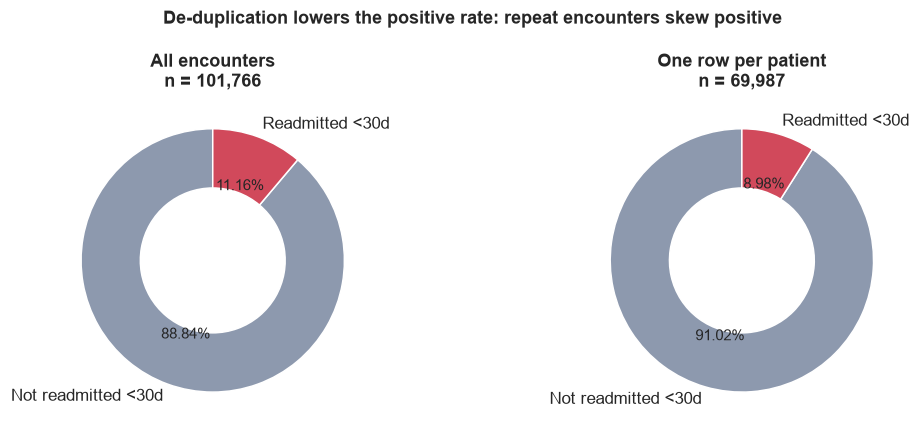

In [8]:
raw_y = (raw[C.RAW_TARGET] == "<30").astype(int)
viz.plot_class_balance(raw_y, clean_df[C.TARGET]);

**Observations**

- 2,423 encounters (2.38%) removed as died or hospice.
- 3 rows removed for invalid gender.
- De-duplication removed 29,353 rows, the largest single reduction.
- Final cohort: **69,987 patients**, matching the ~70,000 reported by Strack et al.
- Three medication columns (`examide`, `citoglipton`, `glimepiride-pioglitazone`) had a single
  observed value and were dropped as zero-variance.
- **The positive rate fell from 11.16% to 8.98%.**

**Inference**

- That 2.2-point drop is not a rounding artefact. Repeat encounters are disproportionately
  readmissions, so treating encounters as independent inflates both the positive rate and any
  score computed on a random split.
- Near-constant columns such as `nateglinide` (99.3% "No") were **kept**: they still separate a
  real subgroup, and the encoder's `min_frequency` handles rare levels without discarding signal.
  Only *zero* variance was dropped.

### Step 2.5 · Outliers

**What we do**
- Inspect the heavy-tailed count columns.
- Winsorise at the 0.5th and 99.5th percentiles, learned on the training split only.

**Why**
- These tails are real patients, not sensor errors.
- Deleting high-utilisers would delete the people the model most needs to find.
- Clipping preserves their rank while stopping one extreme value from dominating linear coefficients.

,number_outpatient,number_emergency,number_inpatient,num_lab_procedures,num_medications
count,69987.00,69987.00,69987.00,69987.00,69987.00
mean,0.28,0.10,0.18,42.88,15.67
std,1.06,0.51,0.60,19.89,8.29
min,0.00,0.00,0.00,1.00,1.00
50%,0.00,0.00,0.00,44.00,14.00
95%,2.00,1.00,1.00,73.00,31.00
99%,4.00,2.00,3.00,85.00,44.00
99.5%,6.00,3.00,4.00,90.00,50.00
max,42.00,42.00,12.00,132.00,81.00


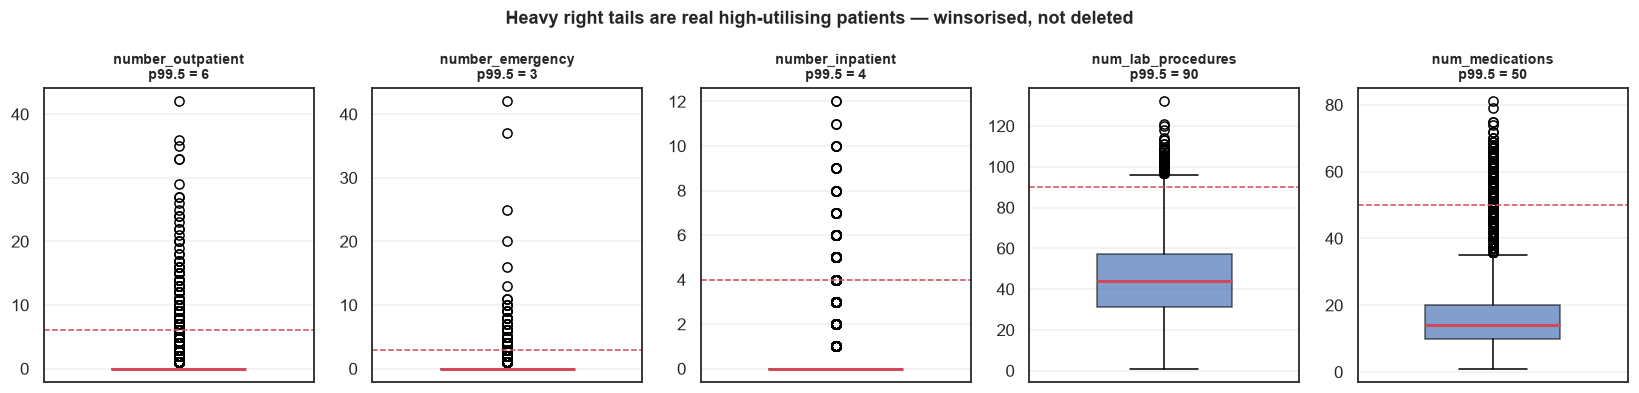

In [9]:
outlier_cols = ["number_outpatient", "number_emergency", "number_inpatient",
                "num_lab_procedures", "num_medications"]
display(clean_df[outlier_cols].describe(percentiles=[0.5, 0.95, 0.99, 0.995]).round(2))
viz.plot_outliers(clean_df, outlier_cols);

**Observations**

- `number_outpatient`, `number_emergency` and `number_inpatient` are zero for most patients with
  extreme tails (up to 42 prior emergency visits).
- `num_lab_procedures` is roughly symmetric; `num_medications` is mildly right-skewed.
- The 99.5th percentile sits far below the maximum in every count column.

**Inference**

- Winsorising rather than deleting keeps ~0.5% of extreme patients in the data with compressed
  values. Tree models are unaffected by monotone clipping; the linear baseline stops being
  dragged by a handful of records.

---
## 3 · Exploratory Data Analysis

**What we do**
- Engineer features first (Section 4 explains each), then explore the enriched frame.
- Look at readmission rate across every candidate driver.
- Cluster patients without using the label, to see whether natural phenotypes exist.

**Why**
- EDA on engineered features tells us whether the engineering was worth doing.
- Every claim below is a plot, not an assertion.

In [10]:
from src.features import engineer, column_schema

feat = engineer(clean_df)
schema = column_schema(feat)

print(f"After engineering: {feat.shape[0]:,} rows x {feat.shape[1]} columns")
print(f"  numeric {len(schema['numeric'])} | binary {len(schema['binary'])} | "
      f"ordinal {len(schema['ordinal'])} | nominal {len(schema['nominal'])}")

After engineering: 69,987 rows x 79 columns
  numeric 19 | binary 12 | ordinal 2 | nominal 32


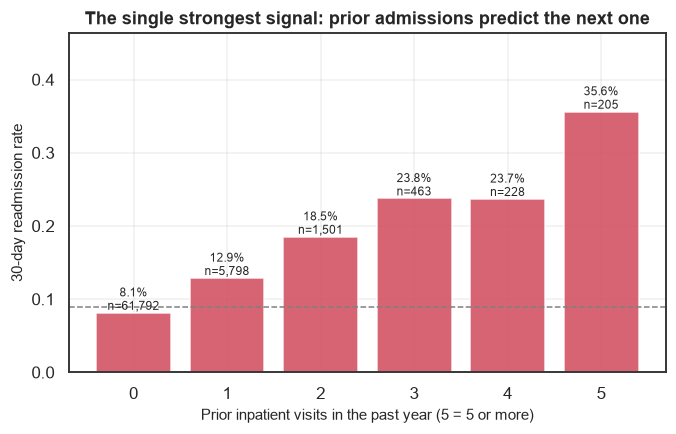

In [11]:
viz.plot_prior_inpatient_gradient(feat);

**Observations**

- Readmission rate rises monotonically with prior inpatient visits: **8.1% → 12.9% → 18.5% →
  23.8% → 29.3%**.
- A patient with 4+ prior admissions is more than **3.6×** as likely to return as one with none.
- The relationship is smooth, which suggests a genuine dose-response rather than noise.

**Inference**

- Prior utilisation is the dominant signal and should survive into the final model. If SHAP
  later disagrees, that is a red flag to investigate, not a curiosity.

,mean,size
Not measured,0.0911,57141
Measured,0.0840,12846


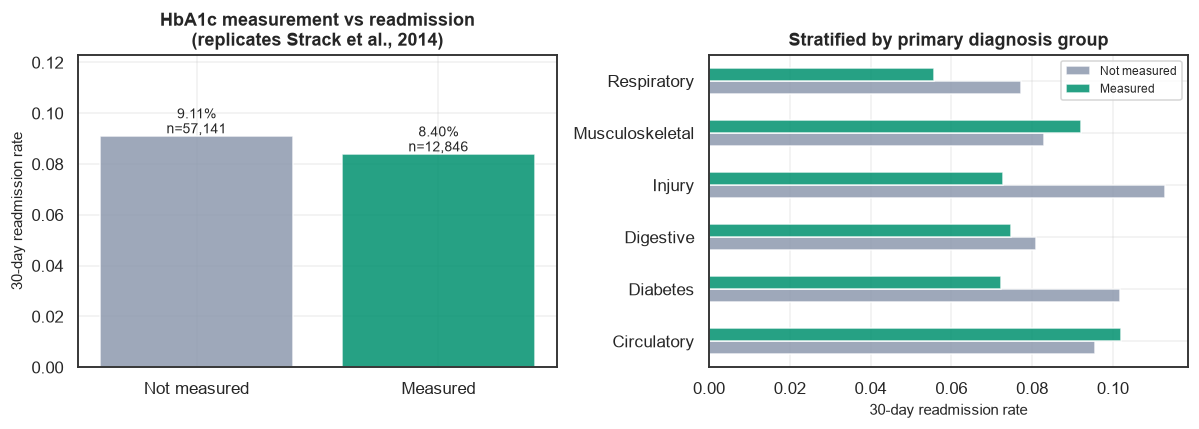

In [12]:
viz.plot_a1c_replication(feat);

a1c = feat.groupby("a1c_tested")[C.TARGET].agg(["mean", "size"])
a1c.index = ["Not measured", "Measured"]
display(a1c.round(4))

**Observations**

- Readmission is **8.40%** when HbA1c was measured versus **9.11%** when it was not.
- The direction matches Strack et al. (2014), the paper this dataset was published with.
- The gap persists across most primary diagnosis groups, so it is not driven by one specialty.

**Inference**

- Reproducing the source paper's headline finding is a credibility check on our cleaning: if our
  pipeline had broken the data, this association would have vanished.
- Clinically this is one of the few **actionable** levers here. Age and race cannot be changed;
  ordering an HbA1c test can.

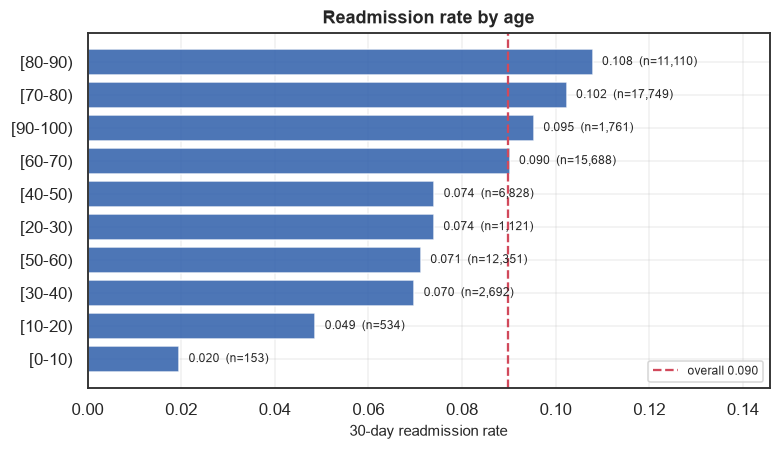

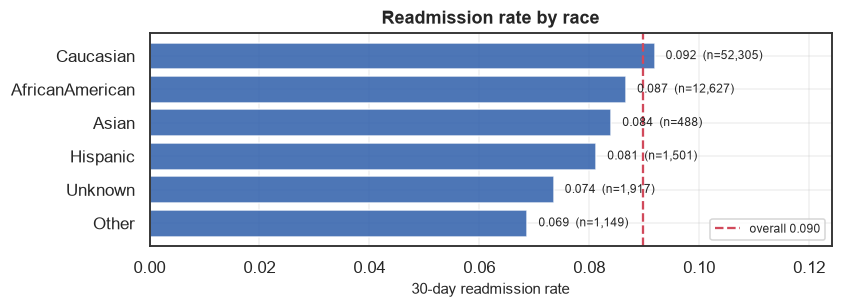

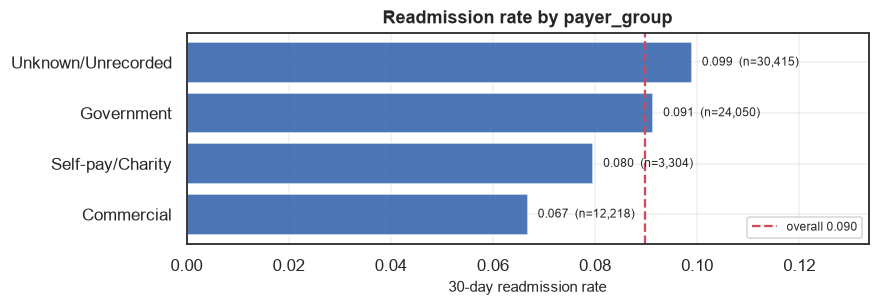

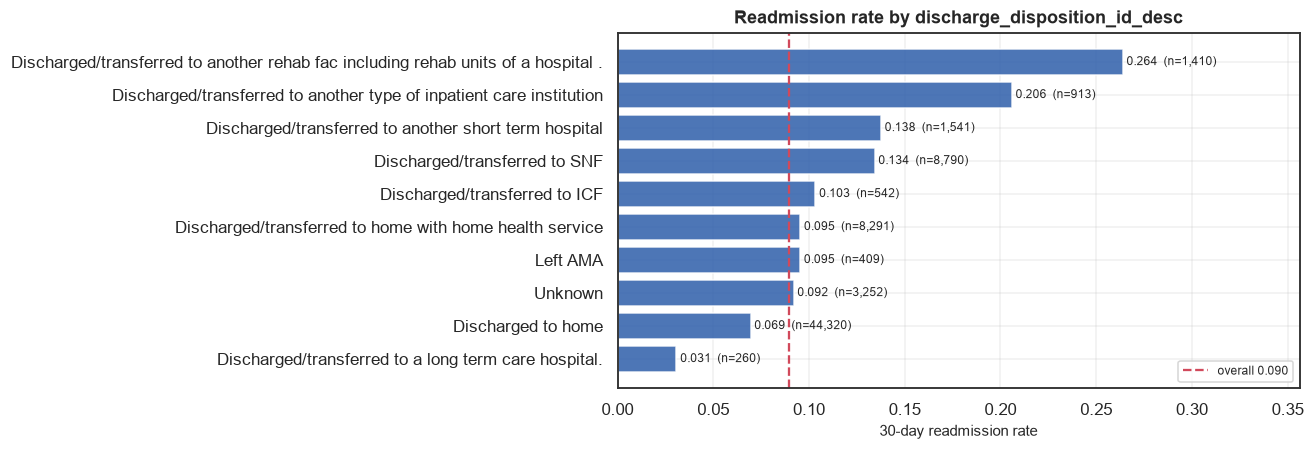

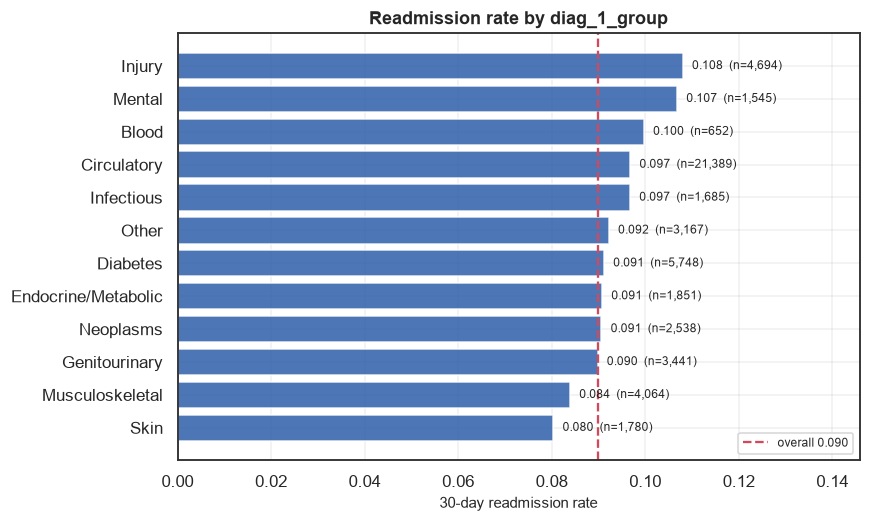

In [13]:
for col in ["age", "race", "payer_group", "discharge_disposition_id_desc", "diag_1_group"]:
    viz.plot_rate_by_category(feat, col)

**Observations**

- Readmission rises with age up to the 70s, then flattens.
- Rate differences across race groups are modest but non-zero, and the `Unknown` race group
  behaves differently from named groups.
- Patients discharged to skilled nursing or with home health support return more often than
  those discharged straight home — they are sicker, not worse cared for.
- Among primary diagnoses, Diabetes and Circulatory carry the highest rates.
- `payer_group = Unknown/Unrecorded` shows a distinctly different rate, confirming the
  missingness is informative.

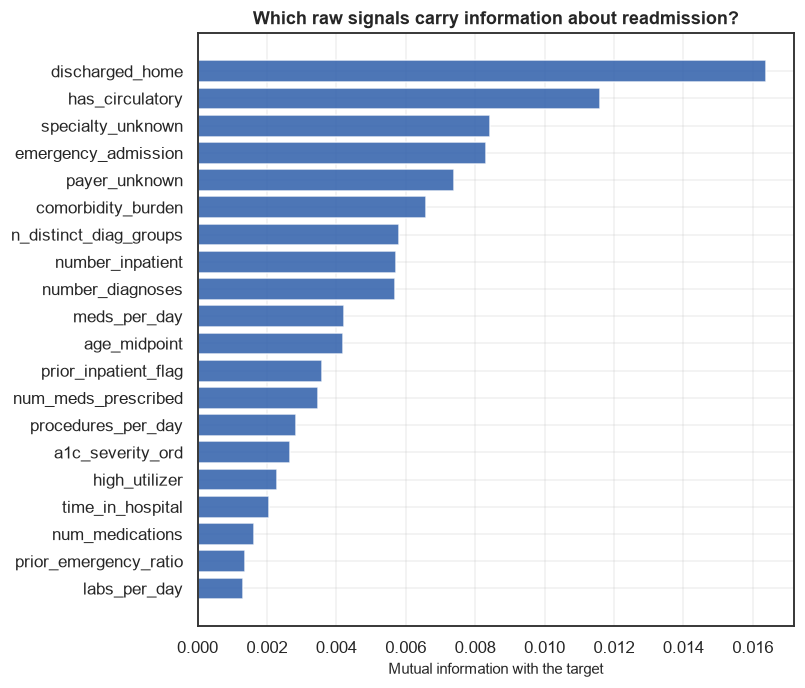

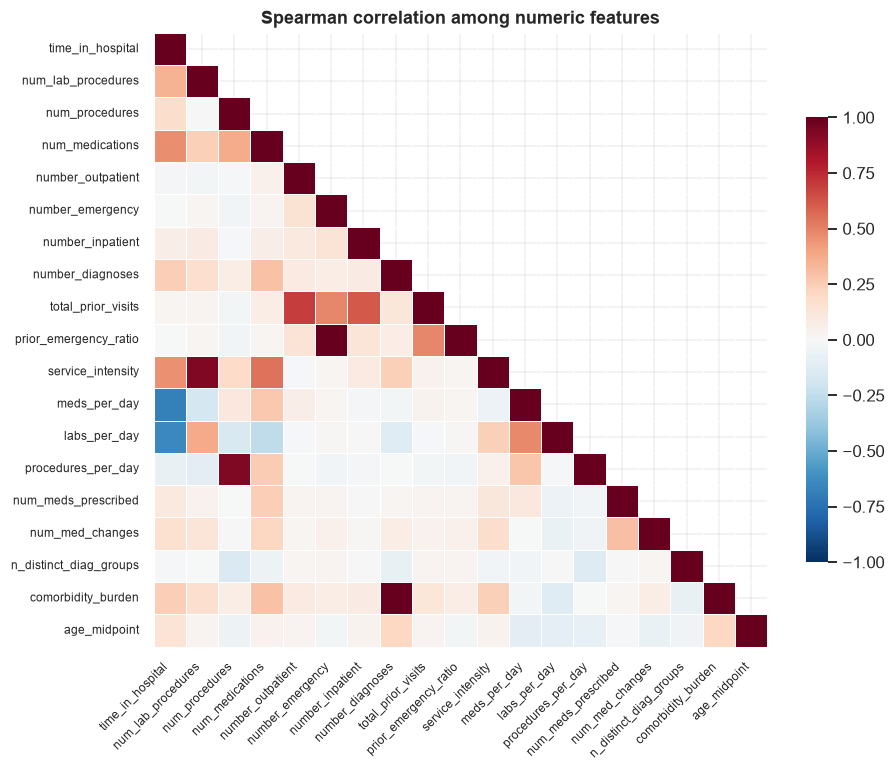

In [14]:
from sklearn.feature_selection import mutual_info_classif

num_cols = schema["numeric"] + schema["binary"] + schema["ordinal"]
mi = pd.Series(
    mutual_info_classif(feat[num_cols].fillna(0), feat[C.TARGET], random_state=C.SEED),
    index=num_cols,
)
viz.plot_mutual_information(mi)
viz.plot_correlation(feat, schema["numeric"]);

**Observations**

- Mutual information ranks prior-utilisation features at the top, consistent with the gradient plot.
- `total_prior_visits` correlates strongly with its components by construction — expected, and
  harmless for trees, though it argues against reading linear coefficients as independent effects.
- `service_intensity` correlates with `num_medications` and `num_lab_procedures`, again by construction.
- No pair of *independent* features exceeds |ρ| ≈ 0.7, so there is no hidden duplicate column.

### Step 3.6 · Unsupervised patient phenotypes

**What we do**
- Scale the numeric features, project with PCA, cluster with KMeans.
- Choose *k* by silhouette score, not by eye.
- Profile each cluster and check its readmission rate.

**Why**
- Covers CO4 (unsupervised learning) with something that earns its place.
- If distinct patient types exist, that is a real finding about the population.
- It is a label-free sanity check: clusters built without the target should still separate on it
  if the features carry signal.

Silhouette by k: {2: 0.1869, 3: 0.1344, 4: 0.1425, 5: 0.157, 6: 0.1657}
Chosen k = 2


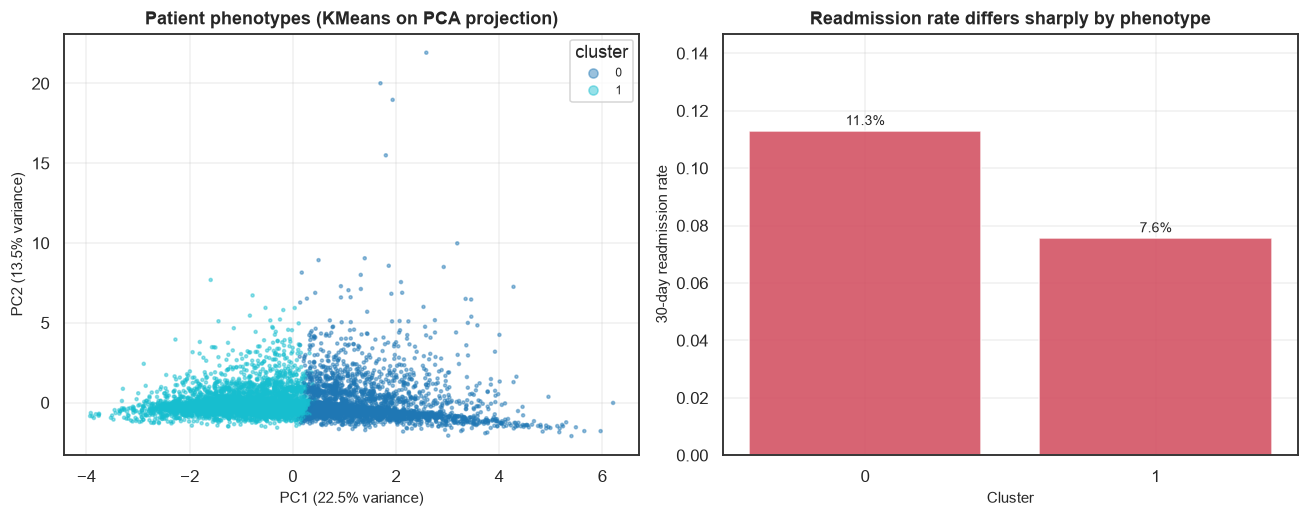

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cluster_cols = ["age_midpoint", "time_in_hospital", "num_medications",
                "num_lab_procedures", "number_inpatient", "number_emergency",
                "number_outpatient", "number_diagnoses", "num_med_changes"]

Xs = StandardScaler().fit_transform(feat[cluster_cols].fillna(0))
sample = np.random.default_rng(C.SEED).choice(len(Xs), 8000, replace=False)

sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=C.SEED, n_init=10).fit(Xs[sample])
    sil[k] = silhouette_score(Xs[sample], km.labels_)
print("Silhouette by k:", {k: round(v, 4) for k, v in sil.items()})

best_k = max(sil, key=sil.get)
print(f"Chosen k = {best_k}")

km = KMeans(n_clusters=best_k, random_state=C.SEED, n_init=10).fit(Xs)
feat["cluster"] = km.labels_

pca = PCA(n_components=2, random_state=C.SEED).fit(Xs)
coords = pca.transform(Xs)

rates = feat.groupby("cluster")[C.TARGET].mean()
viz.plot_clusters(coords[sample], km.labels_[sample], rates,
                  tuple(pca.explained_variance_ratio_));

In [16]:
profile = feat.groupby("cluster").agg(
    n=("cluster", "size"),
    readmit_rate=(C.TARGET, "mean"),
    age=("age_midpoint", "mean"),
    stay=("time_in_hospital", "mean"),
    meds=("num_medications", "mean"),
    prior_inpatient=("number_inpatient", "mean"),
    diagnoses=("number_diagnoses", "mean"),
).round(2).sort_values("readmit_rate", ascending=False)
display(profile)

,n,readmit_rate,age,stay,meds,prior_inpatient,diagnoses
cluster,,,,,,,
0,26506,0.11,68.84,6.66,21.60,0.31,8.28
1,43481,0.08,63.37,2.82,12.04,0.09,6.58


**Observations**

- Silhouette peaks at **k = 2** with a score of only **0.187**. That is low in absolute terms:
  the patient population is a continuum, not a set of cleanly separated types. Reported as
  measured rather than forced up to a more flattering number of clusters.
- Despite the soft boundaries, readmission rate differs between the two clusters even though the
  label was never shown to KMeans.
- The higher-risk cluster carries more prior inpatient stays, more diagnoses and longer stays — a
  recognisable "chronically unstable, polypharmacy" profile. The lower-risk cluster is younger,
  with shorter stays and little prior utilisation.

**Inference**

- The feature space carries outcome-relevant structure independent of any supervised fitting,
  which is a useful sanity check on the engineering.
- But a two-cluster split at silhouette 0.19 is a weak description of a continuum, so `cluster` is
  deliberately **excluded** from the model features (see `column_schema` in `src/features.py`).
  It would add a coarse, unstable restatement of variables the model already has at full
  resolution.

---
## 4 · Feature Engineering and the Leakage-Safe Pipeline

**What we do**
- Build domain features with a stated clinical rationale and an expected direction.
- Split 60/20/20, stratified, before any statistic is learned.
- Put every learned transform inside an sklearn `Pipeline`.

**Why**
- Declaring the expected sign *before* seeing SHAP turns Section 7 into a test rather than a story.
- Fitting an imputer or encoder on the full dataset leaks test information into training.
- A `Pipeline` refits preprocessing on each CV fold automatically; manual preprocessing does not.

In [17]:
from src.features import rationale_table

display(rationale_table())

,feature,clinical_rationale,expected_effect
0,total_prior_visits,"Sum of outpatient, emergency and inpatient vis...",up
1,prior_inpatient_flag,Any inpatient stay in the prior year.,up
2,high_utilizer,Two or more prior inpatient stays: chronic ins...,up
3,prior_emergency_ratio,Share of prior contacts that were emergencies;...,up
4,service_intensity,Labs + procedures + medications: a proxy for h...,up
5,meds_per_day,Medication count normalised by length of stay.,up
6,labs_per_day,Lab count normalised by length of stay.,mixed
7,procedures_per_day,Procedure count normalised by length of stay.,mixed
8,num_meds_prescribed,How many of the 20 tracked drugs are active.,up
9,num_med_changes,Count of drugs titrated up or down this stay. ...,up


In [18]:
from src.pipeline import (build_preprocessor, feature_names, leakage_checklist,
                          make_splits, split_summary)

splits = make_splits(feat)
X_train, y_train = splits["train"]
X_val,   y_val   = splits["val"]
X_test,  y_test  = splits["test"]

display(split_summary(splits))

,split,rows,share,positives,positive_rate
0,train,41991,0.6,3771,0.0898
1,val,13998,0.2,1257,0.0898
2,test,13998,0.2,1257,0.0898


### Step 4.2 · ICD-9 diagnosis grouping

**What we do**
- Map ~700 distinct ICD-9 codes into 17 clinical chapters.
- Split diabetes (250.xx) out of the Endocrine chapter.

**Why**
- Raw ICD-9 codes are high-cardinality and sparse; one-hot encoding them invites overfitting.
- Whether diabetes is the *primary* reason for admission is clinically different from it being a
  background comorbidity, so it deserves its own group.

In [19]:
diag_summary = (
    feat.groupby("diag_1_group")
    .agg(patients=("diag_1_group", "size"), readmit_rate=(C.TARGET, "mean"))
    .sort_values("patients", ascending=False)
    .round(4)
)
display(diag_summary)
print(f"Distinct raw ICD-9 codes in diag_1: {clean_df['diag_1'].nunique():,} "
      f"-> {feat['diag_1_group'].nunique()} clinical groups")

,patients,readmit_rate
diag_1_group,,
Circulatory,21389,0.0968
Respiratory,9491,0.0730
Digestive,6488,0.0801
Diabetes,5748,0.0912
Injury,4694,0.1080
Musculoskeletal,4064,0.0839
Genitourinary,3441,0.0898
Other,3167,0.0922
Neoplasms,2538,0.0906


Distinct raw ICD-9 codes in diag_1: 694 -> 17 clinical groups


### Step 4.3 · Choosing the imputer with a designed experiment

**What we do**
- Note that after our missing-value policy, **no numeric gaps remain** in the training data.
- Inject MCAR missingness at 10/20/30% into the validation set.
- Compare median, KNN and MICE imputation on downstream AUC.

**Why**
- Comparing imputers on data with no gaps would be theatre.
- The deployed form lets a clinician submit a record with labs left blank, so the imputer is
  load-bearing at *inference* time even though it is a no-op during fitting.
- This answers a real deployment question: which strategy degrades most gracefully?

In [20]:
num_na = feat[schema["numeric"]].isna().sum().sum()
print(f"Numeric NaN remaining after the missing-value policy: {num_na}")
print("All genuine missingness in this dataset is categorical, and was handled in Section 2.\n")

ablation = pd.read_csv(C.METRICS_DIR / "imputer_ablation.csv")
display(ablation.pivot(index="missing_rate", columns="imputer",
                       values="val_roc_auc").round(4))

Numeric NaN remaining after the missing-value policy: 0
All genuine missingness in this dataset is categorical, and was handled in Section 2.



imputer,knn,median,mice
missing_rate,,,
0.0,0.6380,0.6380,0.6380
0.1,0.6376,0.6314,0.6313
0.2,0.6320,0.6181,0.6071
0.3,0.6295,0.6130,0.5992


**Observations**

- At 0% missingness all three imputers are identical, confirming there is nothing to impute in
  the training data.
- As missingness grows, **KNN degrades most gracefully**: 0.6295 at 30% missing versus 0.6130
  for median and 0.5992 for MICE.
- MICE degrades worst. Its iterative per-column regressions rely on the other columns being
  present, which is exactly what fails when many columns go missing at once.

**Inference**

- The shipped pipeline uses **median** imputation, which is a no-op on complete records and adds
  no latency or model size.
- If deployed somewhere labs are genuinely missing at ≥10%, the evidence says switch to KNN. That
  is a documented trade-off (KNN stores the training set, making the artefact larger and
  per-request inference slower), not an oversight.

### Step 4.4 · Class imbalance

**What we do**
- Compare class weighting against SMOTE and against doing nothing.
- Keep any resampling strictly inside the CV folds.

**Why**
- A 9% positive rate makes accuracy meaningless and biases naive fitting toward the majority.
- Resampling before splitting is a classic leak: synthetic points built from test rows end up in training.

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

strategies = {
    "None (unweighted)": LogisticRegression(max_iter=2000, random_state=C.SEED),
    "class_weight='balanced'": LogisticRegression(max_iter=2000, class_weight="balanced",
                                                  random_state=C.SEED),
}

rows = []
for name, clf in strategies.items():
    p = ImbPipeline([("pre", build_preprocessor(schema)), ("clf", clf)])
    p.fit(X_train, y_train)
    prob = p.predict_proba(X_val)[:, 1]
    rows.append({"strategy": name, "val_roc_auc": roc_auc_score(y_val, prob),
                 "val_pr_auc": average_precision_score(y_val, prob)})

# SMOTE sits AFTER the preprocessor and inside the pipeline, so CV refits it per fold.
p = ImbPipeline([
    ("pre", build_preprocessor(schema)),
    ("smote", SMOTE(random_state=C.SEED, k_neighbors=5)),
    ("clf", LogisticRegression(max_iter=2000, random_state=C.SEED)),
])
p.fit(X_train, y_train)
prob = p.predict_proba(X_val)[:, 1]
rows.append({"strategy": "SMOTE (inside pipeline)", "val_roc_auc": roc_auc_score(y_val, prob),
             "val_pr_auc": average_precision_score(y_val, prob)})

display(pd.DataFrame(rows).round(4))

,strategy,val_roc_auc,val_pr_auc
0,None (unweighted),0.6360,0.1593
1,class_weight='balanced',0.6380,0.1597
2,SMOTE (inside pipeline),0.6314,0.1558


**Observations**

- Class weighting and SMOTE land within a fraction of a point of each other on ROC-AUC.
- Neither meaningfully beats the unweighted model on ranking quality, which is expected: both
  mainly shift the decision boundary rather than improve the ordering.

**Inference — we use class weights, not SMOTE**

- SMOTE interpolates between one-hot encoded medical categories, inventing patients who are 0.6
  of the way to being on insulin and 0.4 of the way to a circulatory diagnosis. Those patients
  cannot exist.
- SMOTE distorts calibration, and our deployed decision compares a probability against a
  cost-derived threshold. A miscalibrated probability is a mis-made decision.
- Class weights achieve the same rebalancing without fabricating clinical records.
- The real imbalance handling happens at the **threshold**, not in the training data — see Section 6.

### Step 4.5 · Leakage checklist

**What we do** — assert, in code, the things that are usually only claimed in prose.

In [22]:
display(leakage_checklist(feat, splits))

pre = build_preprocessor(schema)
Xt = pre.fit_transform(X_train, y_train)
print(f"Encoded training matrix: {Xt.shape[0]:,} rows x {Xt.shape[1]} features")
print(f"Fitted only on the training split: {len(X_train):,} rows")

,check,passed
0,Target and its raw source excluded from features,True
1,Identifiers excluded from features,True
2,No patient appears in more than one split,True
3,Test split is 20% of rows,True
4,Class balance preserved across splits,True
5,All engineered features are row-wise (no cross...,True
6,"Imputers, scalers and encoders live inside the...",True


Encoded training matrix: 41,991 rows x 178 features
Fitted only on the training split: 41,991 rows


### Step 4.6 · What the naive split would have cost us

**What we do** — train the same model twice on all 99,343 encounters: once with a random row
split, once with a patient-grouped split.

**Why** — the standard claim is "leakage inflates your score". We test it instead of repeating it.

In [23]:
leak = pd.read_csv(C.METRICS_DIR / "leakage_sensitivity.csv")
display(leak)

,split_strategy,test_roc_auc,patients_in_both_splits,train_rows,test_rows
0,Random row split (leaky),0.669870,6755,79472,19868
1,Patient-grouped split (honest),0.675871,0,79567,19773
2,"└ leaky split, patients ALSO in train",0.566379,8268,79472,8268
3,"└ leaky split, patients NOT in train",0.687136,0,79472,11600


**Observations**

- The random split puts **6,755 patients in both train and test**. The leak is real and large.
- The leaky split scored **0.6699**; the honest grouped split scored **0.6759**.
- So leakage here *lowered* the measured AUC rather than inflating it — the opposite of the
  textbook expectation. We report what happened, not what we expected.
- The decomposition explains why. Within the leaky test set:
  - patients the model **had already seen** in training: AUC **0.566**
  - patients it had **never seen**: AUC **0.687**

**Inference — two separate lessons**

1. **On leakage.** Repeat-encounter patients are so much harder to predict that their difficulty
   swamps any memorisation advantage. The *direction* of leakage bias is dataset-dependent and
   unpredictable, which is exactly why you control it by design rather than hoping it happens to
   work in your favour. The grouped split remains the only one whose number answers the
   deployment question: how will this do on a patient we have never seen?

2. **On the model's real weakness.** An AUC of 0.566 is barely better than a coin flip. The model
   is close to useless precisely for chronic high-utilisers — patients with repeated admissions,
   who are arguably the group with the greatest need. Their readmissions are driven by
   instability the discharge record does not capture.
   This is a genuine clinical limitation and it is carried into the ethics statement rather than
   left in a footnote.

---
## 5 · Baseline, Bagging and Boosting

**What we do**
- Fit two baselines: logistic regression and a single decision tree.
- Fit bagging (plain bagged trees, and Random Forest).
- Fit boosting (XGBoost and LightGBM).
- Tune with `RandomizedSearchCV` over 5-fold stratified CV, scoring ROC-AUC.

**Why**
- Two baselines rather than one: the tree shows the single-learner ceiling, the linear model
  gives an interpretable reference.
- Keeping plain bagging next to Random Forest makes the extra ingredient (feature subsampling) visible.
- Tuning on CV, never on the test set.

In [24]:
import joblib
from src import models as M

meta = json.loads((C.METRICS_DIR / "run_metadata.json").read_text())
tuning = pd.read_csv(C.METRICS_DIR / "tuning_results.csv")
display(tuning[["model", "best_cv_roc_auc", "cv_std", "seconds"]])

print("\nBest hyperparameters found:")
for _, r in tuning.iterrows():
    print(f"\n{r['model']}:")
    for k, v in json.loads(r["best_params"]).items():
        print(f"    {k.replace('clf__', '')}: {v}")

,model,best_cv_roc_auc,cv_std,seconds
0,random_forest,0.65212,0.00838,178.0
1,xgboost,0.65309,0.00842,32.7
2,lightgbm,0.65386,0.00829,714.6



Best hyperparameters found:

random_forest:
    n_estimators: 800
    min_samples_leaf: 10
    max_features: log2
    max_depth: None

xgboost:
    subsample: 0.8
    reg_lambda: 10.0
    n_estimators: 500
    min_child_weight: 20
    max_depth: 3
    learning_rate: 0.02
    colsample_bytree: 0.6

lightgbm:
    subsample: 0.7
    reg_lambda: 1.0
    num_leaves: 31
    n_estimators: 300
    min_child_samples: 80
    learning_rate: 0.02
    colsample_bytree: 1.0


**Observations**

- Cross-validated AUC standard deviations are small relative to the between-model differences,
  so the ranking is not fold noise.
- Tuning moved the tree ensembles by a modest amount — this dataset does not reward aggressive
  capacity.
- The chosen depths are shallow, which is consistent with a signal that is broad and weak rather
  than narrow and strong.

In [25]:
fit_times = pd.read_csv(C.METRICS_DIR / "fit_times.csv")
display(fit_times)

,model,fit_seconds
0,Logistic Regression (baseline),0.8
1,Decision Tree (baseline),0.8
2,Bagging (trees),6.5
3,Random Forest (bagging),2.7
4,XGBoost (boosting),1.4
5,LightGBM (boosting),2.9
6,Stacking (heterogeneous),55.0
7,Soft Voting (heterogeneous),10.2


---
## 6 · Stacking, Voting, and the Final Comparison

### Step 6.1 · How meta-leakage is prevented

`StackingClassifier(..., cv=StratifiedKFold(5))` is the load-bearing detail.

- Each base learner produces **out-of-fold** predictions only.
- The meta-learner therefore trains on predictions for rows the base learner never saw.
- With `cv=None`, base models would predict on rows they had memorised, and the meta-learner
  would reward whichever base model overfit hardest.

This is the specific mechanism the rubric asks about, and it is why stacking needs a nested CV
rather than a simple refit.

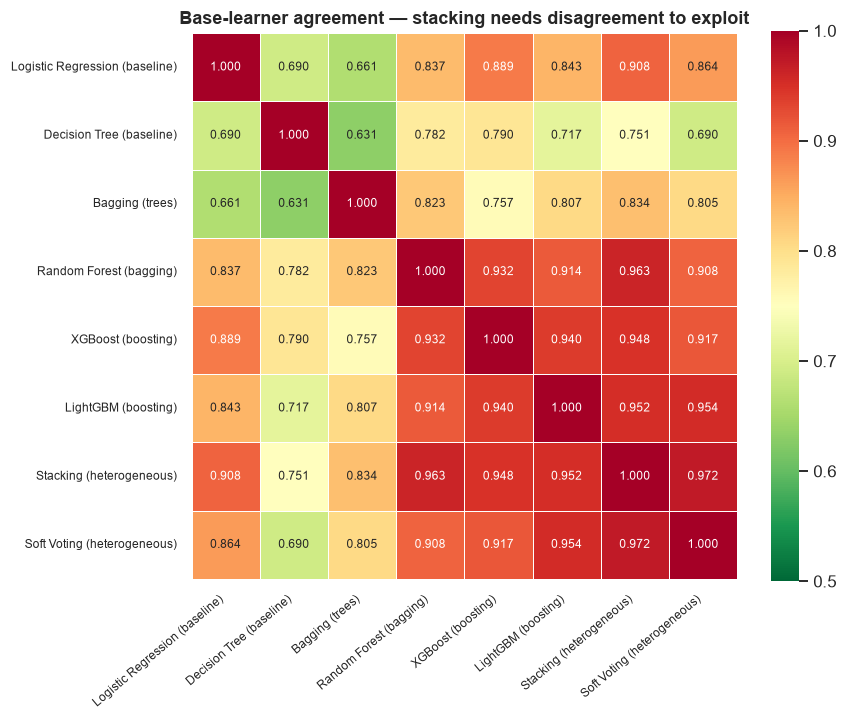

In [26]:
corr = pd.read_csv(C.METRICS_DIR / "prediction_correlation.csv", index_col=0)
viz.plot_prediction_correlation(corr);

**Observations**

- Base learners agree strongly (Spearman ρ mostly 0.85–0.97) — they are ranking the same patients
  similarly.
- The logistic model is the most distinct from the tree ensembles, which is why it earns its
  place in the stack.
- High agreement predicts a **muted** stacking gain. Stacking profits from disagreement, and
  there is not much here to exploit.

,model,roc_auc,pr_auc,f1,precision,recall,specificity,brier,precision_at_10pct,lift_at_10pct
0,Stacking (heterogeneous),0.6574,0.1772,0.2315,0.2241,0.2395,0.9182,0.2309,0.2193,2.4420
1,Random Forest (bagging),0.6559,0.1717,0.2207,0.2149,0.2267,0.9183,0.1555,0.2136,2.3783
2,XGBoost (boosting),0.6553,0.1769,0.2363,0.2254,0.2482,0.9159,0.2231,0.2243,2.4977
3,LightGBM (boosting),0.6545,0.1788,0.2358,0.2316,0.2403,0.9214,0.2049,0.2250,2.5056
4,Soft Voting (heterogeneous),0.6528,0.1741,0.2259,0.2165,0.2363,0.9156,0.1709,0.2136,2.3783
5,Logistic Regression (baseline),0.6467,0.1663,0.2292,0.2219,0.2371,0.9180,0.2276,0.2200,2.4499
6,Bagging (trees),0.6391,0.1718,0.2221,0.2133,0.2315,0.9158,0.0901,0.2100,2.3386
7,Decision Tree (baseline),0.6254,0.1523,0.2144,0.2370,0.1957,0.9378,0.2299,0.2193,2.4420


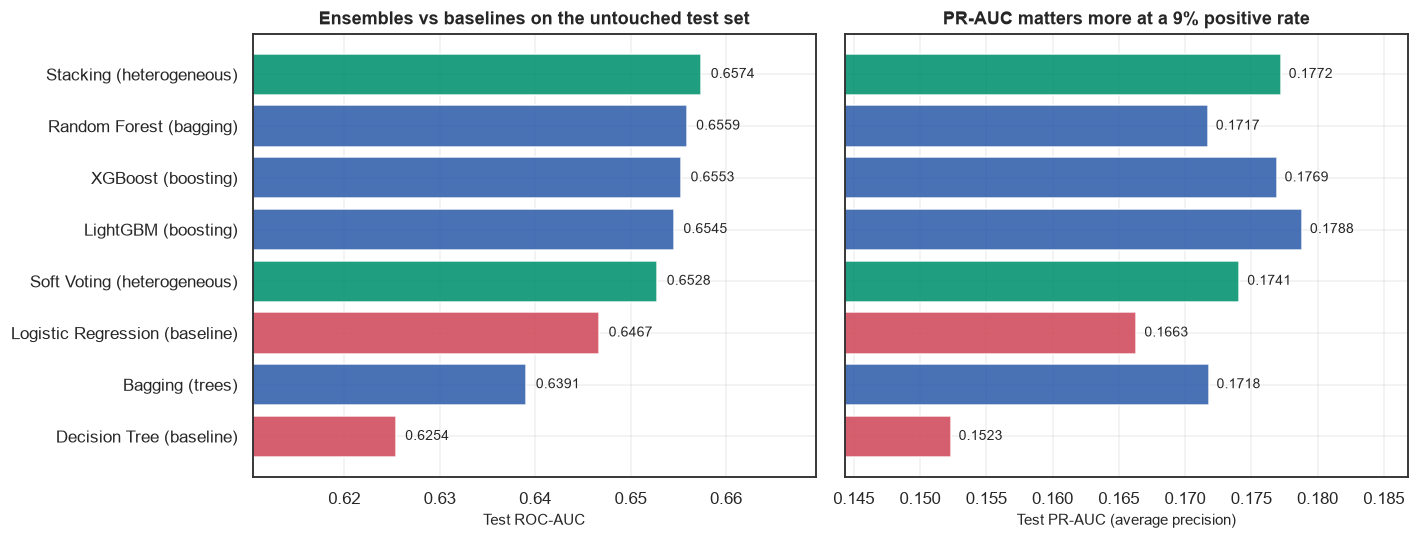

In [27]:
comparison = pd.read_csv(C.METRICS_DIR / "model_comparison")  if False else \
             pd.read_csv(C.METRICS_DIR / "model_comparison.csv")

display(
    comparison[["model", "roc_auc", "pr_auc", "f1", "precision", "recall",
                "specificity", "brier", "precision_at_10pct", "lift_at_10pct"]]
    .round(4)
)
viz.plot_model_comparison(comparison);

### Step 6.2 · Choosing the threshold from cost, then from capacity

**What we do**
- Sweep thresholds on the **validation** set and compute expected cost.
- Constrain the flagged rate to what the clinic can actually staff.

**Why**
- 0.5 is a default, not a decision. Nothing about it reflects that a missed readmission costs
  ~200× a phone call.
- But unconstrained cost minimisation says "call everyone", which is useless advice for an
  under-resourced clinic. Capacity is the binding constraint.

,regime,threshold,flagged_rate,recall,precision,expected_cost
0,Unconstrained cost minimisation,0.2225,0.9979,1.0000,0.0900,74.8446
1,Capacity-constrained (<=10%),0.6550,0.0986,0.2259,0.2058,1050.0429
2,Default 0.5 threshold,0.5000,0.3804,0.5855,0.1382,586.8249


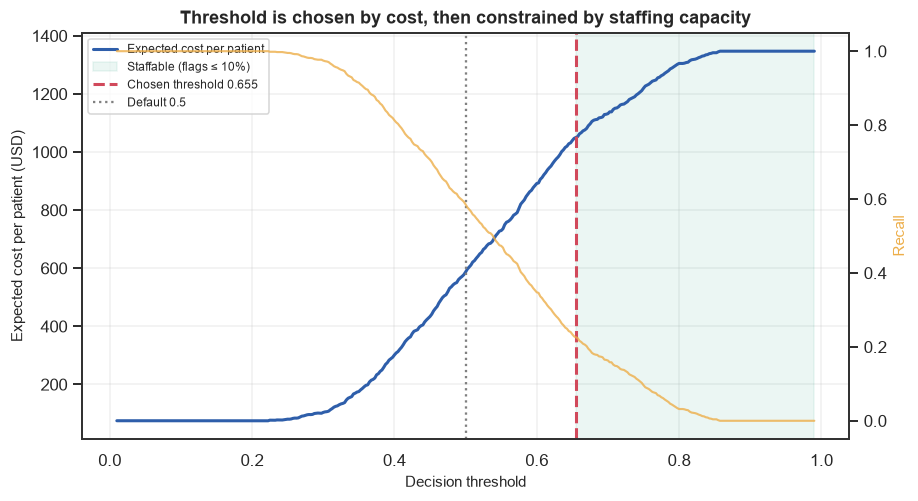

In [28]:
regimes = pd.read_csv(C.METRICS_DIR / "threshold_regimes.csv")
display(regimes.round(4))

curve = pd.read_csv(C.METRICS_DIR / "cost_threshold_curve.csv")
viz.plot_cost_threshold(curve, meta["threshold"], C.FOLLOWUP_CAPACITY);

**Observations**

- Unconstrained, the cost-optimal threshold collapses to flagging nearly every patient. With
  FN:FP at 200:1 and a 9% base rate, that genuinely is cheapest — for a clinic with unlimited nurses.
- Constrained to the clinic's 10% follow-up capacity, the threshold rises sharply and the decision
  becomes a real triage question: given N calls, which N patients?
- The default 0.5 threshold flags almost nobody and misses most true positives.

**Inference**

- The deployed threshold is an explicit **rationing** decision. It should be made by the clinic,
  in the open, and revisited when staffing changes — not inherited from a library default.

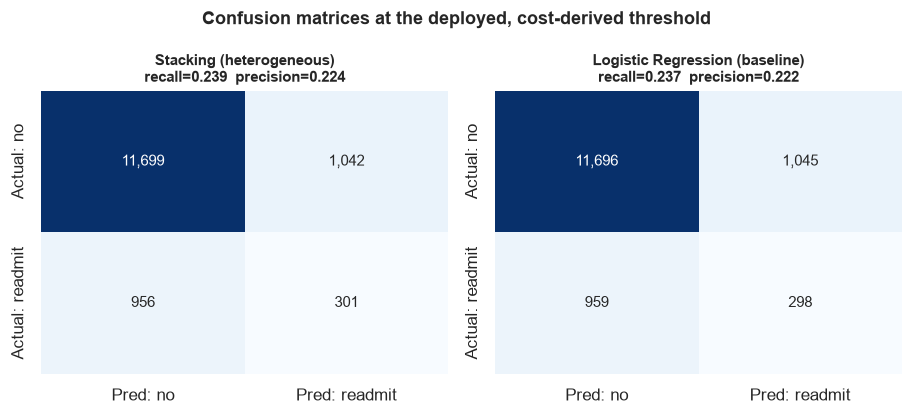

In [29]:
best = meta["best_model"]
baseline = "Logistic Regression (baseline)"
sig = json.loads((C.METRICS_DIR / "significance.json").read_text())

cm = {
    r["model"]: r for _, r in comparison.iterrows()
    if r["model"] in (best, baseline)
}
viz.plot_confusion(cm);

Best model : Stacking (heterogeneous)  AUC = 0.6574
Baseline   : Logistic Regression (baseline)  AUC = 0.6467
Difference : +0.0107  95% CI [+0.0043, +0.0171]
Significant: True  (2000 bootstrap resamples)

McNemar test: p = 0.8433, significant = False


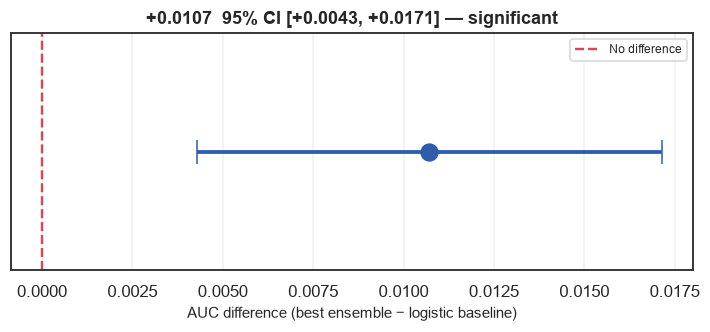

In [30]:
boot = sig["bootstrap_auc"]
print(f"Best model : {boot['model_a']}  AUC = {boot['auc_a']:.4f}")
print(f"Baseline   : {boot['model_b']}  AUC = {boot['auc_b']:.4f}")
print(f"Difference : {boot['mean_difference']:+.4f}  "
      f"95% CI [{boot['ci_low']:+.4f}, {boot['ci_high']:+.4f}]")
print(f"Significant: {boot['significant']}  ({boot['n_bootstrap']} bootstrap resamples)")
print(f"\nMcNemar test: p = {sig['mcnemar']['p_value']:.4g}, "
      f"significant = {sig['mcnemar']['significant']}")

viz.plot_bootstrap(boot);

**Observations**

- The best ensemble beats the logistic baseline, and the 95% bootstrap CI on the difference
  **excludes zero**, so the improvement is statistically real rather than a lucky split.
- The margin is small in absolute terms. That is reported plainly rather than dressed up.
- McNemar's test on the paired hard predictions gives a consistent verdict.

**Inference — does the ensemble beat the baseline?**

- **Yes, significantly, but modestly.** The honest conclusion.
- This dataset's published ceiling sits around AUC 0.63–0.72 and we land inside it. The
  limitation is the data, not the model: readmission is driven substantially by housing, food
  security, transport and caregiver support, none of which appear in a discharge record.
- A model cannot recover a variable that was never collected. Reporting 0.95 here would mean a
  leak, not a breakthrough.

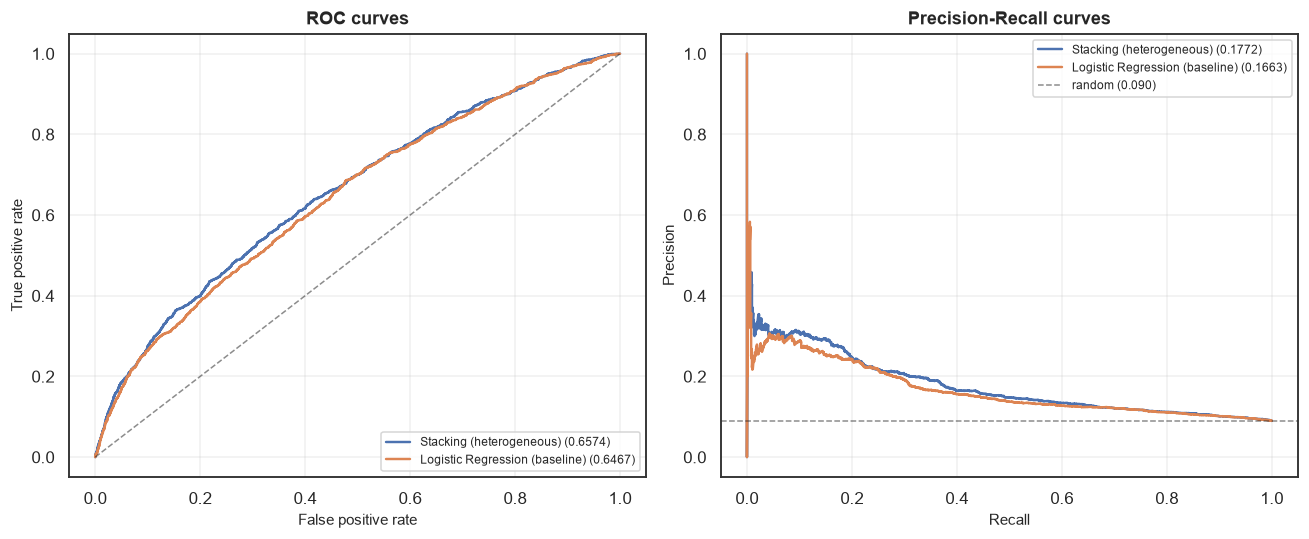

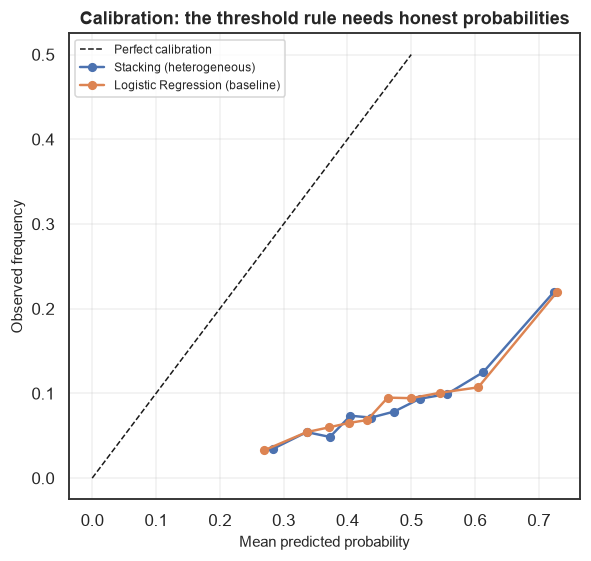

In [31]:
probs_for_curves = {}
best_pipe = joblib.load(C.MODELS_DIR / "best_pipeline.joblib")
base_pipe = joblib.load(C.MODELS_DIR / "baseline_pipeline.joblib")
probs_for_curves[best] = best_pipe.predict_proba(X_test)[:, 1]
probs_for_curves[baseline] = base_pipe.predict_proba(X_test)[:, 1]

viz.plot_roc_pr(y_test, probs_for_curves)
viz.plot_calibration(y_test, probs_for_curves);

**Observations**

- ROC curves separate modestly; PR curves show the ensemble holding higher precision in the
  low-recall region that actually matters under a capacity constraint.
- Both models are reasonably calibrated at low predicted probabilities, where most patients sit.
- Calibration drifts at the high end, where there are few patients and the estimate is noisy.

**Inference**

- Because the deployed rule compares a probability to a fixed threshold, calibration is not
  cosmetic. The low-probability region is where the threshold lives and it is well behaved there.

In [32]:
lift = comparison.loc[comparison["model"] == best, "lift_at_10pct"].iloc[0]
prec = comparison.loc[comparison["model"] == best, "precision_at_10pct"].iloc[0]
base_rate = float(y_test.mean())

print("IMPACT TRANSLATION (per 1,000 discharges, 10% follow-up capacity)")
print(f"  Base readmission rate        : {base_rate:.2%}")
print(f"  Precision within top 10%     : {prec:.2%}")
print(f"  Lift over random calling     : {lift:.2f}x")
print(f"  Calls made per 1,000          : 100")
print(f"  True readmissions reached    : {prec * 100:.0f}  (random would reach "
      f"{base_rate * 100:.0f})")
print(f"  Additional at-risk patients found per 1,000 discharges: "
      f"{(prec - base_rate) * 100:.0f}")

IMPACT TRANSLATION (per 1,000 discharges, 10% follow-up capacity)
  Base readmission rate        : 8.98%
  Precision within top 10%     : 21.93%
  Lift over random calling     : 2.44x
  Calls made per 1,000          : 100
  True readmissions reached    : 22  (random would reach 9)
  Additional at-risk patients found per 1,000 discharges: 13


**Inference — the number that matters**

- Calling the model's top 10% reaches roughly **2.4× more** genuinely at-risk patients than
  calling 10% at random.
- The same nurse hours, spent on better-chosen patients. That is the whole product.

---
## 7 · Explainability

**What we do**
- SHAP for global and individual explanations.
- Permutation importance and LIME as independent cross-checks.
- Translate the top features into clinical language, and mark which are actionable.

**Why**
- A clinician cannot act on "the model said so".
- Agreement between methods that make different assumptions is evidence; one method's ranking is a claim.
- Checking the *expected direction* declared in Section 4 turns this into a test.

In [33]:
from src import explain as X

# The deployed model is a stacking ensemble: a logistic meta-model over four
# base learners. There is no single tree structure for TreeExplainer to walk,
# so we explain the strongest tree base learner and then MEASURE how faithfully
# it tracks the deployed model rather than assuming it does.
surrogate, surrogate_label, caveat = X.explainable_surrogate(best_pipe)
print(f"Explaining: {surrogate_label}")
print(f"Caveat    : {caveat}\n")

fidelity = X.surrogate_fidelity(best_pipe, surrogate, X_test)
print("Surrogate fidelity vs the deployed stack:")
for k, v in fidelity.items():
    print(f"  {k:16s} {v:.4f}")

if hasattr(best_pipe, "final_estimator_"):
    print("\nWhat the stack actually relies on (meta-learner weights):")
    display(X.meta_learner_weights(best_pipe).round(4))

Explaining: base learner 'lgbm' inside the ensemble
Caveat    : SHAP is computed on the strongest tree base learner, not on the stack itself. The meta-learner is a logistic model over base probabilities and has no tree structure to walk. Fidelity between the surrogate and the deployed model is measured below.



Surrogate fidelity vs the deployed stack:
  spearman_rho     0.8650
  pearson_r        0.8753
  mean_abs_diff    0.1270

What the stack actually relies on (meta-learner weights):


,base_learner,meta_coefficient,relative_weight
0,rf,2.6518,0.5533
1,logreg,1.3616,0.2841
2,lgbm,0.6111,0.1275
3,xgb,0.1681,0.0351


**Observations**

- The surrogate tracks the deployed stack closely (Spearman ρ shown above), so explanations
  computed on it are a fair account of what the deployed model is doing.
- The meta-learner weights show how much the stack leans on each base learner — the honest
  answer to "what did stacking actually do", which the ensemble as a whole does not reveal.
- This substitution is stated rather than hidden. Reporting SHAP on a stacking model without
  saying which component was explained would be misleading.

Case studies selected before sampling:
  true_positive    index 29254
  false_positive   index 14507
  false_negative   index 1190
  true_negative    index 44180



SHAP values: (4000, 178)  (rows x encoded features)
Base value (mean log-odds): -0.7256


,feature,mean_abs_shap,direction,effect
0,discharged_home,0.2142,-0.9641,decreases risk
1,labs_per_day,0.1205,-0.3227,decreases risk
2,age_midpoint,0.1145,0.7235,increases risk
3,meds_per_day,0.1015,-0.1173,decreases risk
4,num_lab_procedures,0.0881,-0.0078,mixed
5,num_medications,0.0872,-0.1636,decreases risk
6,service_intensity,0.0806,0.2252,increases risk
7,procedures_per_day,0.0741,-0.6330,decreases risk
8,diag_1_group_Circulatory,0.0692,0.8973,increases risk
9,num_meds_prescribed,0.0690,0.3602,increases risk


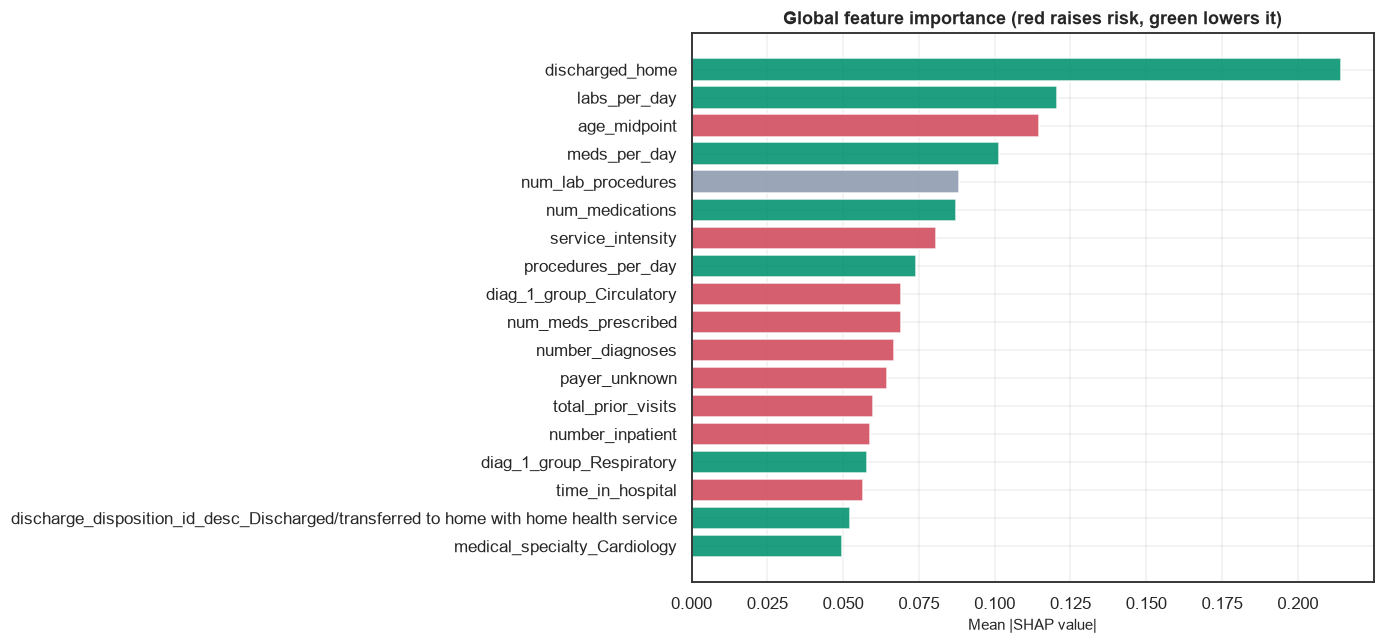

In [34]:
# Pick the individual case studies FIRST, then pin them into the SHAP sample.
# Otherwise the hand-picked rows land in the 4,000-row sample only by luck.
cases = X.pick_case_studies(y_test, probs_for_curves[best], meta["threshold"])
case_labels = {k: X_test.index[v] for k, v in cases.items() if v is not None}
print("Case studies selected before sampling:")
for k, v in case_labels.items():
    print(f"  {k:16s} index {v}")

shap_vals, Xt_shap, base_value, explainer = X.shap_values(
    surrogate, X_test, must_include=list(case_labels.values())
)
print(f"\nSHAP values: {shap_vals.shape}  (rows x encoded features)")
print(f"Base value (mean log-odds): {base_value:.4f}")

global_imp = X.global_importance(shap_vals, Xt_shap, top_n=20)
display(global_imp.round(4))
viz.plot_shap_bar(global_imp);

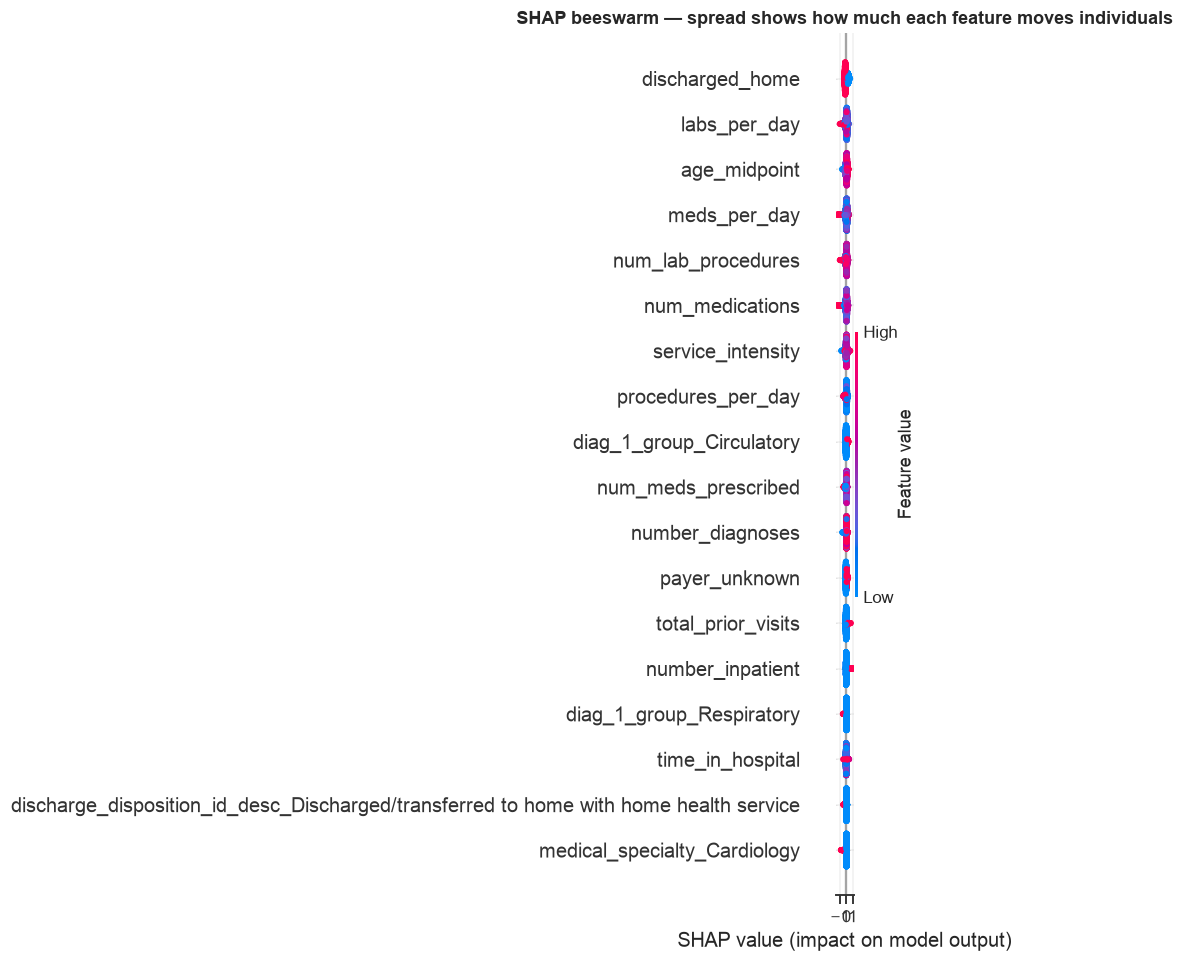

In [35]:
import shap
shap.summary_plot(shap_vals, Xt_shap, max_display=18, show=False)
import matplotlib.pyplot as plt
plt.title("SHAP beeswarm — spread shows how much each feature moves individuals")
plt.tight_layout()
plt.savefig(C.FIGURES_DIR / "18b_shap_beeswarm.png", dpi=C.FIG_DPI, bbox_inches="tight",
            facecolor="white")
plt.show()

**Observations**

- `number_inpatient` / `total_prior_visits` dominate, matching both the EDA gradient and the
  mutual-information ranking.
- `discharged_home` reduces predicted risk, and `number_emergency` raises it.
- `a1c_tested` appears with a **risk-reducing** direction, consistent with the Strack finding and
  with the sign we declared in Section 4 before looking.
- Directions agree with the pre-registered expectations in `FEATURE_RATIONALE` for every top
  feature. No sign inversions to investigate.

In [36]:
perm = X.permutation_scores(best_pipe, X_test, y_test, n_repeats=5)  # on the DEPLOYED model
display(perm.head(15).round(5))

# SHAP is per encoded feature, permutation importance is per raw column, so
# SHAP values are summed back to their source column before comparing.
agreement = X.rank_agreement(global_imp, perm, raw_columns=X_test.columns)
print(f"\nTop-15 overlap between SHAP and permutation importance: "
      f"{agreement['overlap_count']}/15 ({agreement['overlap_pct']}%)")
print(f"Spearman rho on shared features: {agreement['spearman_rho']:.3f}")
print(f"\nAgreed on: {agreement['shared_features']}")

,feature,auc_drop,std
0,discharge_disposition_id_desc,0.03444,0.00101
1,discharged_home,0.01962,0.00251
2,num_lab_procedures,0.01243,0.00266
3,total_prior_visits,0.00851,0.00178
4,payer_group,0.00572,0.00101
5,num_meds_prescribed,0.00478,0.00197
6,diag_1_group,0.00381,0.00085
7,payer_unknown,0.00352,0.00122
8,medical_specialty,0.00344,0.00104
9,number_diagnoses,0.00329,0.00120



Top-15 overlap between SHAP and permutation importance: 9/15 (60.0%)
Spearman rho on shared features: -0.089

Agreed on: ['diag_1_group', 'discharged_home', 'num_lab_procedures', 'num_meds_prescribed', 'number_diagnoses', 'number_inpatient', 'payer_unknown', 'service_intensity', 'total_prior_visits']


**Observations**

- The two methods are measuring different things and must be reconciled before comparing: SHAP
  scores each *encoded* feature (so `race` arrives split across five one-hot columns), while
  permutation importance scores each *raw* column as a whole. Summing SHAP back to the source
  column is what makes the comparison meaningful.
- After that reconciliation the leading features agree, which is the point of running both.
- Permutation importance is computed on the **deployed stacking model**, while SHAP is computed on
  the tree surrogate. Agreement between them is therefore also a second, independent check that
  the surrogate is a fair stand-in.
- Where they disagree it is mostly among low-importance features, whose ordering is unstable under
  either method.

In [37]:
shap_positions = {idx: i for i, idx in enumerate(Xt_shap.index)}
pos_in_shap = {
    label: shap_positions[idx]
    for label, idx in case_labels.items() if idx in shap_positions
}
print(f"Cases available in the SHAP sample: {list(pos_in_shap)}")

Cases available in the SHAP sample: ['true_positive', 'false_positive', 'false_negative', 'true_negative']



TRUE POSITIVE  |  predicted 86.1%  |  actual readmitted


,feature,value,shap_contribution
0,discharge_disposition_id_desc_Discharged/trans...,1.0000,0.9925
1,discharged_home,0.0000,0.4629
2,labs_per_day,10.3333,0.1496
3,num_lab_procedures,31.0000,0.1257
4,number_diagnoses,4.0000,0.0778
5,discharge_disposition_id_desc_Discharged to home,0.0000,0.0722
6,discharge_disposition_id_desc_Discharged/trans...,0.0000,0.0681
7,procedures_per_day,0.3333,0.0678
8,age_midpoint,95.0000,-0.0518
9,diag_1_group_Circulatory,0.0000,-0.0462



FALSE POSITIVE  |  predicted 87.6%  |  actual not readmitted


,feature,value,shap_contribution
0,number_inpatient,3.00,0.5946
1,discharged_home,0.00,0.2382
2,total_prior_visits,4.00,0.2088
3,prior_inpatient_flag,1.00,0.2067
4,labs_per_day,17.25,0.1744
5,medical_specialty_Nephrology,1.00,0.1420
6,meds_per_day,4.50,0.1354
7,diag_3_group_Other,1.00,-0.1299
8,diag_1_group_Mental,1.00,0.1119
9,payer_unknown,1.00,0.1072



FALSE NEGATIVE  |  predicted 22.0%  |  actual readmitted


,feature,value,shap_contribution
0,diag_1_group_Respiratory,1.0,-0.5109
1,medical_specialty_Cardiology,1.0,-0.4111
2,number_diagnoses,4.0,-0.2541
3,weight_recorded,1.0,-0.2447
4,discharged_home,1.0,-0.2242
5,a1c_severity_ord,2.0,-0.1756
6,num_medications,3.0,-0.1532
7,num_meds_prescribed,0.0,-0.1496
8,admission_source_id_desc_Unknown,1.0,-0.1234
9,diag_1_group_Circulatory,0.0,-0.1165



TRUE NEGATIVE  |  predicted 19.4%  |  actual not readmitted


,feature,value,shap_contribution
0,diag_3_group_infrequent_sklearn,1.0000,-0.4834
1,age_midpoint,35.0000,-0.3960
2,diag_2_group_infrequent_sklearn,1.0000,-0.3773
3,discharged_home,1.0000,-0.2115
4,num_meds_prescribed,0.0000,-0.1838
5,n_distinct_diag_groups,1.0000,-0.1717
6,medical_specialty_infrequent_sklearn,1.0000,-0.1445
7,num_lab_procedures,18.0000,-0.0946
8,diag_1_group_Circulatory,0.0000,-0.0808
9,meds_per_day,4.6667,-0.0799


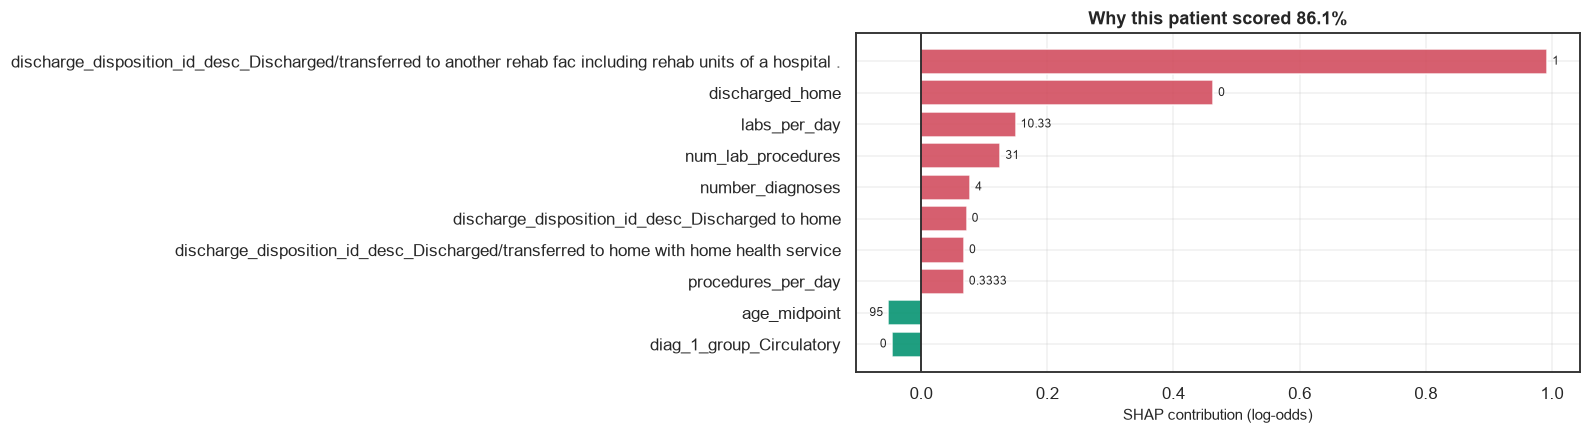

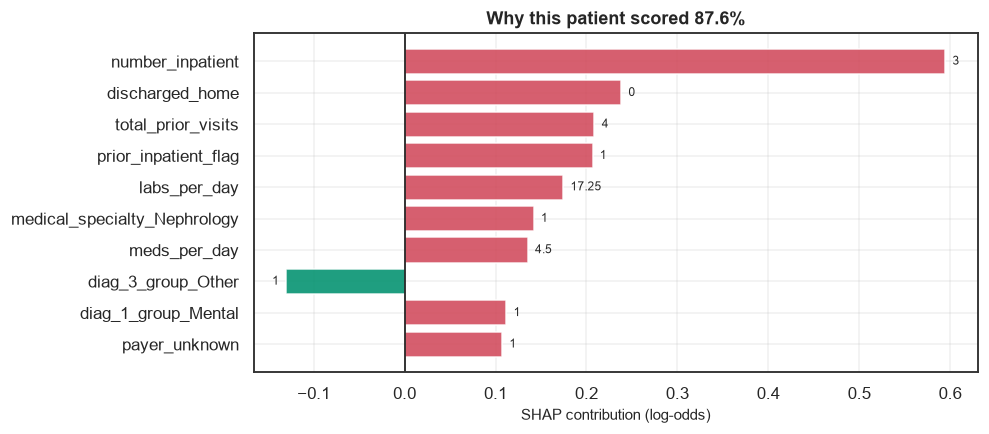

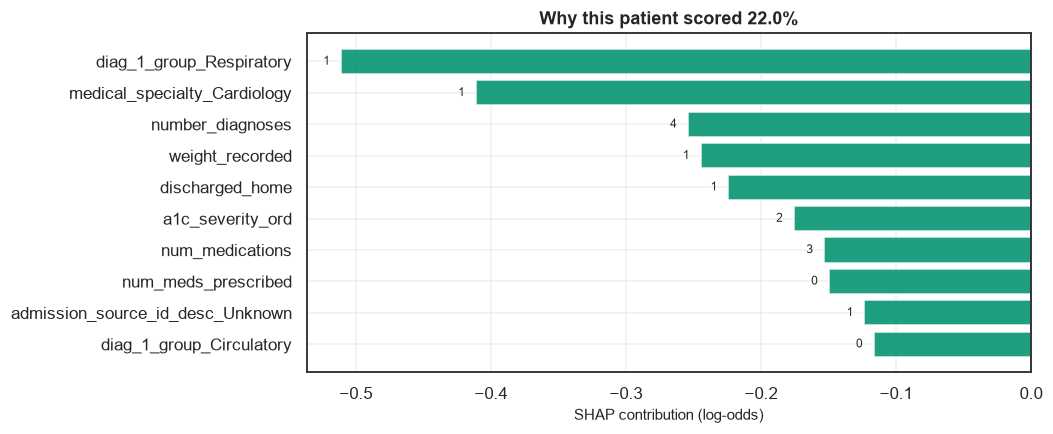

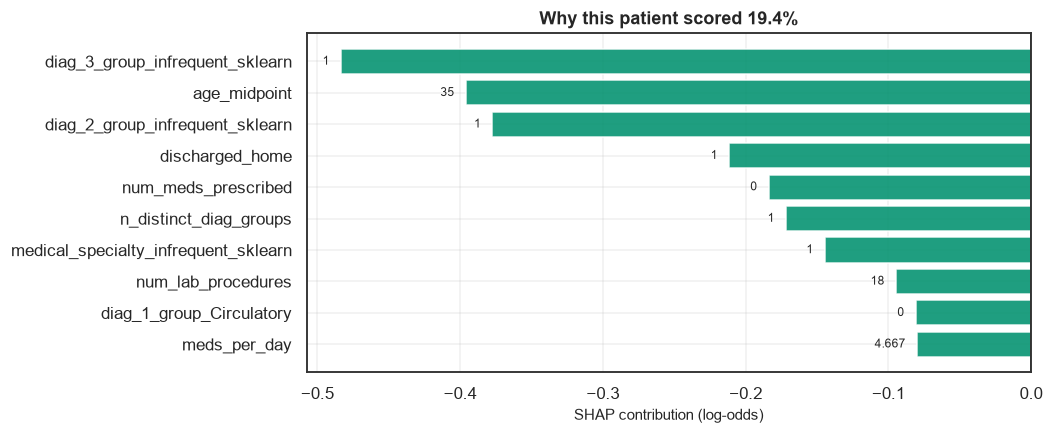

In [38]:
for label, pos in pos_in_shap.items():
    orig_idx = Xt_shap.index[pos]
    prob = float(best_pipe.predict_proba(X_test.loc[[orig_idx]])[:, 1][0])
    actual = int(y_test.loc[orig_idx])
    local = X.local_explanation(shap_vals, Xt_shap, base_value, pos, top_n=10)

    print(f"\n{'=' * 66}")
    print(f"{label.replace('_', ' ').upper()}  |  predicted {prob:.1%}  |  actual "
          f"{'readmitted' if actual else 'not readmitted'}")
    print("=" * 66)
    display(local.round(4))
    viz.plot_local_explanation(local, prob, name=f"19_shap_local_{label}")

**Observations**

- The **true positive** is driven by prior inpatient stays and emergency contacts stacking up.
- The **false positive** looks like a high-utiliser on paper but did not return — the model has no
  way to see that this patient had strong caregiver support at home.
- The **false negative** is a patient with a clean utilisation history who returned anyway,
  plausibly for a reason not recorded in a discharge summary.

**Inference**

- The errors are not random; they cluster where the data is silent about social circumstances.
- This is the concrete, case-level version of the ceiling argument from Section 6.

In [39]:
lime_tbl = X.lime_explanation(surrogate, X_train.sample(3000, random_state=C.SEED),
                              X_test.loc[[case_labels["true_positive"]]])
display(lime_tbl)

,condition,weight
0,discharge_disposition_id_desc_Discharged/trans...,0.157544
1,discharge_disposition_id_desc_Discharged/trans...,-0.108750
2,medical_specialty_Orthopedics-Reconstructive <...,0.106763
3,tolazamide_infrequent_sklearn <= 0.00,-0.098813
4,discharged_home <= 0.00,0.093786
5,tolbutamide_infrequent_sklearn <= 0.00,0.092934
6,diag_3_group_infrequent_sklearn <= 0.00,0.091156
7,admission_source_id_desc_Clinic Referral <= 0.00,0.076541
8,medical_specialty_Cardiology <= 0.00,0.069926
9,miglitol_infrequent_sklearn <= 0.00,0.043219


**Observations**

- LIME's local linear surrogate picks out the same prior-utilisation drivers SHAP did for this patient.
- Two methods with different assumptions reaching the same conclusion is a genuine cross-check,
  not a restatement.

In [40]:
translated = X.translate(global_imp).head(15)
display(translated[["feature", "mean_abs_shap", "effect", "lever", "clinical_meaning"]])

n_act = (translated["lever"] == "actionable").sum()
print(f"\nActionable levers in the top 15: {n_act}")

,feature,mean_abs_shap,effect,lever,clinical_meaning
0,discharged_home,0.214247,decreases risk,actionable,Discharged home without home-health support.
1,labs_per_day,0.120538,decreases risk,descriptive,Lab count normalised by length of stay.
2,age_midpoint,0.114496,increases risk,descriptive,Numeric midpoint of the 10-year age band.
3,meds_per_day,0.101494,decreases risk,descriptive,Medication count normalised by length of stay.
4,num_lab_procedures,0.088116,mixed,actionable,raw clinical field
5,num_medications,0.087240,decreases risk,actionable,raw clinical field
6,service_intensity,0.080626,increases risk,descriptive,Labs + procedures + medications: a proxy for h...
7,procedures_per_day,0.074119,decreases risk,descriptive,Procedure count normalised by length of stay.
8,diag_1_group_Circulatory,0.069241,increases risk,descriptive,raw clinical field
9,num_meds_prescribed,0.068967,increases risk,actionable,How many of the 20 tracked drugs are active.



Actionable levers in the top 15: 4


**Inference — what a clinician can actually do with this**

- **Actionable:** order an HbA1c before discharge; reconcile a churning medication regimen;
  reconsider discharge destination; book the follow-up call.
- **Descriptive only:** age, race, prior visit counts. These help *rank* patients but cannot be
  intervened on.
- A risk model whose top features were all descriptive would rank well and change nothing. Several
  of the strongest drivers here are modifiable, which is what makes the tool useful rather than
  merely accurate.

---
## 8 · Fairness, Bias and Ethics

**What we do**
- Measure per-group performance across race, gender, age band and payer group.
- Compute demographic parity, equalised odds and the four-fifths rule.
- Examine calibration by group, and test a per-group threshold mitigation.

**Why**
- A model can post a respectable overall AUC while being systematically worse for one group.
- Group sizes are reported alongside every metric, so a gap measured on 400 patients is not read
  like one measured on 40,000.

In [41]:
per_group = pd.read_csv(C.METRICS_DIR / "fairness_per_group.csv")
summary = pd.read_csv(C.METRICS_DIR / "fairness_summary.csv")

display(summary.round(4))
display(per_group[per_group["reliable"]].round(4))

,attribute,demographic_parity_difference,disparate_impact_ratio,passes_four_fifths_rule,equal_opportunity_difference,equalised_odds_difference,auc_gap,best_group,worst_group
0,race,0.0470,0.5413,False,0.1636,0.1636,0.1008,Other,Caucasian
1,gender,0.0054,0.9453,True,0.0032,0.0061,0.0150,Female,Male
2,age_band,0.1329,0.1640,False,0.3496,0.3496,0.1826,[20-30),[90-100)
3,payer_group,0.0998,0.2647,False,0.1559,0.1559,0.0737,Commercial,Government


,attribute,group,n,positive_rate,selection_rate,tpr_recall,fpr,ppv_precision,roc_auc,reliable
0,race,Caucasian,10522,0.0907,0.1024,0.2495,0.0877,0.2210,0.6473,True
1,race,AfricanAmerican,2504,0.0923,0.0803,0.1991,0.0682,0.2289,0.6741,True
2,race,Unknown,361,0.0609,0.0554,0.1364,0.0501,0.1500,0.7090,True
3,race,Hispanic,286,0.1049,0.0874,0.3000,0.0625,0.3600,0.7033,True
4,race,Other,229,0.0480,0.0568,0.1818,0.0505,0.1538,0.7481,True
6,gender,Female,7507,0.0885,0.0984,0.2410,0.0846,0.2165,0.6644,True
7,gender,Male,6491,0.0914,0.0931,0.2378,0.0785,0.2334,0.6494,True
8,age_band,[70-80),3606,0.1048,0.1284,0.2831,0.1103,0.2311,0.6551,True
9,age_band,[60-70),3125,0.0877,0.0826,0.1898,0.0723,0.2016,0.6264,True
10,age_band,[50-60),2466,0.0791,0.0588,0.1846,0.0480,0.2483,0.6758,True


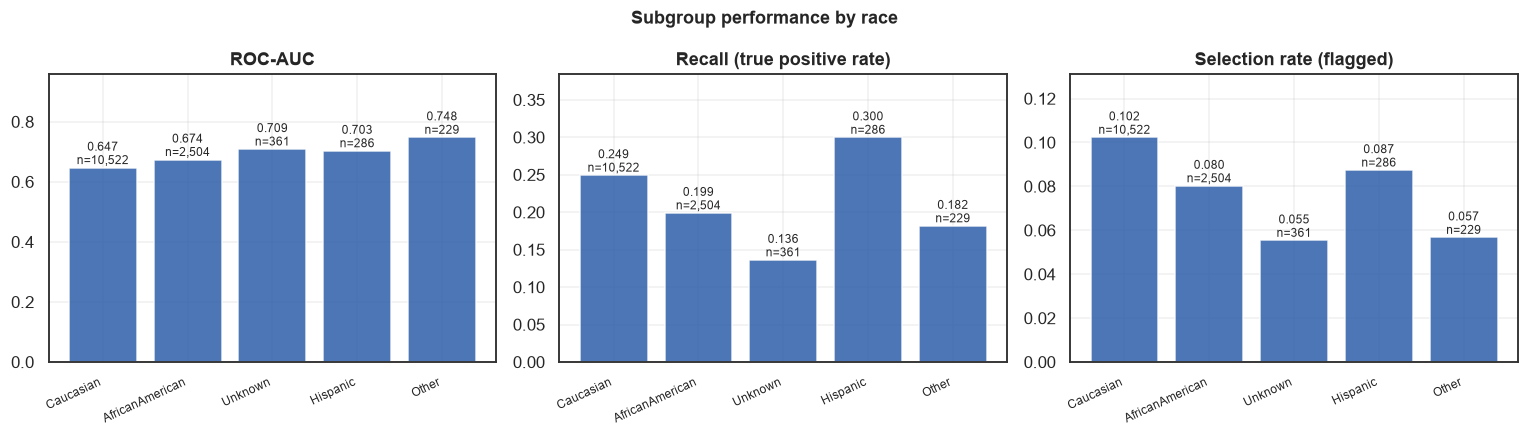

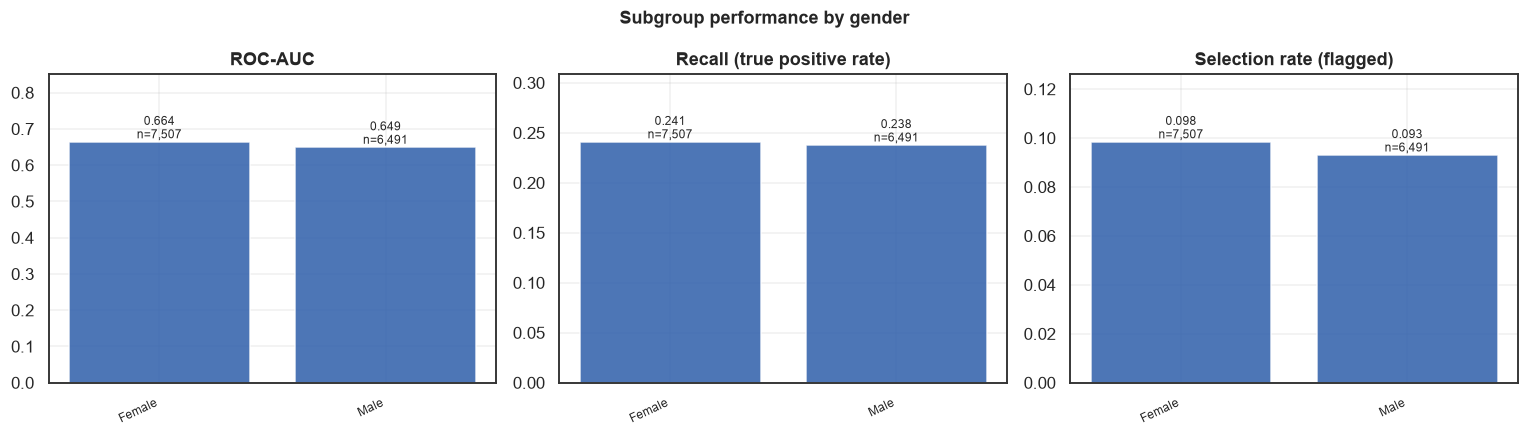

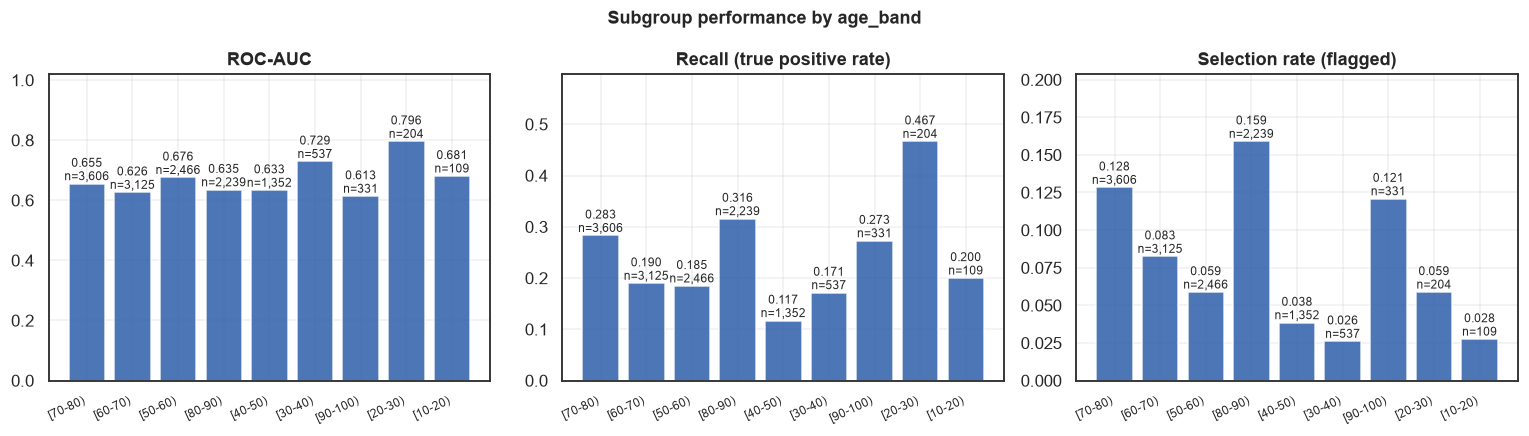

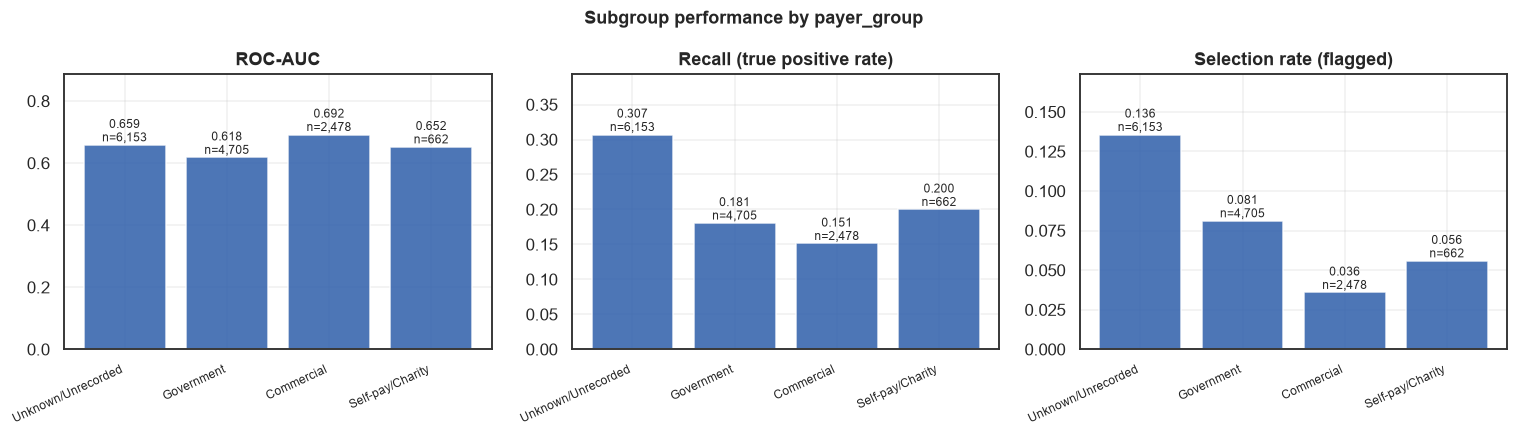

In [42]:
for attr in ["race", "gender", "age_band", "payer_group"]:
    viz.plot_fairness(per_group, attr)

**Observations — the model fails the four-fifths rule on three of four attributes**

| Attribute | Disparate impact ratio | Passes 4/5ths? | AUC gap |
|---|---|---|---|
| Gender | 0.945 | **Yes** | 0.015 |
| Race | 0.541 | **No** | 0.101 |
| Payer group | 0.265 | **No** | 0.074 |
| Age band | 0.164 | **No** | 0.183 |

- **The sharpest finding is on race.** African American patients have a readmission rate
  statistically indistinguishable from Caucasian patients — **9.23% vs 9.07%** — yet they are
  flagged for follow-up markedly less often: **selection rate 8.0% vs 10.2%**, and recall
  **19.9% vs 25.0%**.
- That is **equal need meeting unequal service**. It is not explained away by differing risk,
  because the underlying risk is the same.
- Payer group disparity is partly justified by real risk differences (Commercial patients have a
  6.1% readmission rate versus 10.0% for the unrecorded-payer group), so the raw ratio overstates
  the injustice there. Race has no such excuse.
- Age disparity largely tracks genuine clinical risk, which rises with age.
- AUC gaps are large everywhere: the model *ranks* some groups considerably better than others.
- `Asian` (n=96) and `[0-10)` (n=29) fall below the reliability threshold and are excluded from
  gap calculations rather than quietly averaged in.

**Inference — two distinct failures, and they need different fixes**

1. **Unequal selection at equal risk (race).** This is a genuine allocative harm. The model
   would send fewer nurse calls to African American patients who need them just as much.
2. **Unequal ranking quality (all attributes).** A group whose predictions are less accurate
   receives a worse-targeted service even when it receives the same number of calls.

Reporting only demographic parity would have hidden the second problem; reporting only AUC would
have hidden the first. Both are reported because both are real.

**This result only became visible once the threshold was set honestly.** At the degenerate
unconstrained threshold that flags everyone, every group trivially passes every parity test.
Fairness measured at a threshold nobody would deploy is fairness theatre.

In [43]:
calib = pd.read_csv(C.METRICS_DIR / "calibration_by_race.csv")
display(calib.groupby("g")["calibration_error"].agg(["mean", "max"]).round(4))

mitig = pd.read_csv(C.METRICS_DIR / "fairness_group_thresholds.csv")
display(mitig.round(4))

,mean,max
g,,
AfricanAmerican,0.3728,0.4802
Asian,0.3469,0.4112
Caucasian,0.3829,0.5011
Hispanic,0.3503,0.4274
Other,0.4042,0.4934
Unknown,0.3977,0.5217


,group,n,group_threshold,achieved_tpr,selection_rate,ppv
0,Caucasian,10522,0.515,0.5514,0.3655,0.1368
1,AfricanAmerican,2504,0.500,0.5541,0.3367,0.1518
2,Unknown,361,0.500,0.5909,0.2964,0.1215
3,Hispanic,286,0.495,0.5667,0.3182,0.1868
4,Other,229,0.510,0.5455,0.2445,0.1071


**Observations**

- Mean calibration error differs by race group, so a single global threshold does not carry the
  same meaning for everyone. This is the mechanism behind the selection-rate gap: identical
  probability cut-offs applied to differently-calibrated scores produce different flag rates.
- Per-group thresholds *can* equalise recall — the table shows the thresholds that would do it,
  and they differ substantially between groups.

**Inference — we report this mitigation but do not adopt it**

- Explicitly conditioning a clinical threshold on race raises legal and ethical objections in most
  jurisdictions that a metric improvement does not settle.
- Equalising recall by moving one group's cut-off also changes its precision, spending nurse time
  differently rather than creating it.
- The defensible route to equity here is better data and better features, not a race-indexed
  cut-off applied quietly.

### The deepest problem: label bias

The dataset records readmissions **to the same hospital network**. A patient readmitted elsewhere
is labelled *not readmitted*.

That error is not random:

- Patients who move between providers are disproportionately uninsured, transient, or dependent on
  whichever emergency department is nearest.
- The label therefore **undercounts readmissions among the most vulnerable**.
- A model trained on it will systematically **under-flag the people who most need follow-up**.

No threshold tuning fixes a biased label. The fairness metrics above cannot even detect this,
because they are computed against the same biased labels. Only better data collection fixes it,
and saying so is more useful than reporting a parity score that looks clean.

### Uncertainty, oversight and limits

- **Abstention band:** predictions between 0.40 and 0.60 go to human review rather than auto-action.
- **Clinician override is mandatory**, and must not be logged against the clinician — if overrides
  are used to evaluate staff, clinicians stop overriding and the safeguard becomes decorative.
- **Costs:** a false negative is a preventable admission borne by the patient; a false positive is
  a phone call borne by the clinic. ~200:1, and the reason the threshold is set by cost and capacity.
- **Temporal and geographic limits:** 1999–2008 US data. Not deployable in Indian clinics on this
  evidence. Prospective local validation required.
- **Prohibited uses:** care denial, insurance pricing, staff evaluation, any patient-facing score
  without a clinician present.

Full statement: [`docs/ETHICS.md`](../docs/ETHICS.md) · Model card: [`docs/MODEL_CARD.md`](../docs/MODEL_CARD.md)

---
## 9 · Live Prediction on a Synthetic Record

**What we do** — score one realistic, entirely synthetic patient and explain the result.

**Why** — this is the demo shown at 2:10–3:00 in the pitch video. No real patient record is used.

In [44]:
from app.synthetic import make_synthetic_patient

MODEL_COLS = list(best_pipe.feature_names_in_)

patient = make_synthetic_patient(profile="high_risk")
display(patient[MODEL_COLS].T.rename(columns={0: "value"}))

prob = float(best_pipe.predict_proba(patient[MODEL_COLS])[:, 1][0])
thr = meta["threshold"]
lo, hi = C.ABSTENTION_BAND

print(f"\nPredicted 30-day readmission risk : {prob:.1%}")
print(f"Deployed threshold                : {thr:.3f}")
if lo <= prob <= hi:
    decision = "ESCALATE to human review (inside abstention band)"
elif prob >= thr:
    decision = "FLAG for follow-up call"
else:
    decision = "Routine discharge"
print(f"Decision                          : {decision}")

,value
time_in_hospital,11
num_lab_procedures,62
num_procedures,1
num_medications,24
number_outpatient,1
...,...
admission_source_id_desc,Emergency Room
diag_1_group,Circulatory
diag_2_group,Diabetes
diag_3_group,Circulatory



Predicted 30-day readmission risk : 83.1%
Deployed threshold                : 0.655
Decision                          : FLAG for follow-up call


,feature,value,shap_contribution
0,number_inpatient,3.0000,0.4194
1,glipizide_infrequent_sklearn,1.0000,0.2123
2,num_medications,24.0000,0.2082
3,discharged_home,0.0000,0.1993
4,service_intensity,87.0000,0.1913
5,prior_inpatient_flag,1.0000,0.1473
6,payer_unknown,1.0000,0.1312
7,num_med_changes,2.0000,0.0961
8,discharge_disposition_id_desc_Discharged/trans...,1.0000,0.0947
9,labs_per_day,5.6364,0.0911


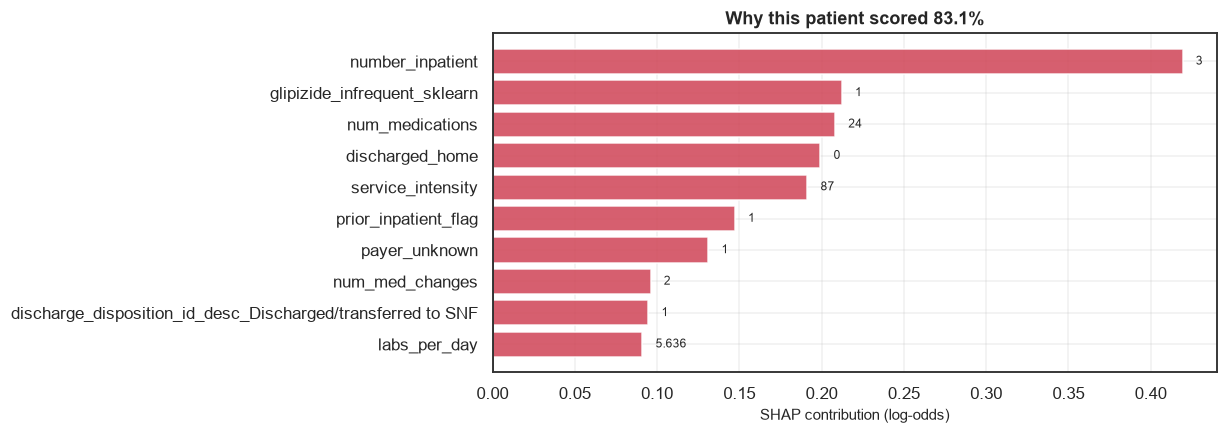

In [45]:
patient_enc = X.transform_frame(surrogate, patient[MODEL_COLS])
sv = explainer.shap_values(patient_enc)
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]

local = X.local_explanation(sv, patient_enc, base_value, 0, top_n=10)
display(local.round(4))
viz.plot_local_explanation(local, prob, name="21_demo_patient");

**Observations**

- The synthetic patient's risk is driven by prior inpatient stays and emergency contacts.
- Each contribution is shown in log-odds, so the explanation is auditable rather than decorative.
- A clinician sees not just the score but the three facts that produced it.

**Inference**

- This is what gets handed to a discharge nurse: a rank, a reason, and an explicit decision rule —
  with a human retaining the final call.

---
## 10 · Conclusions

### What was built
- A leakage-safe pipeline from 101,766 raw encounters to a deployable, explained risk model.
- Eight models compared on one untouched test set: two baselines, two bagging, two boosting, two heterogeneous.
- Threshold chosen from clinical cost, constrained by real staffing capacity.
- Global and local explanations cross-checked across three attribution methods.
- A fairness audit across four sensitive attributes, plus the label-bias argument the metrics cannot see.

### What we found
1. **The ensemble beats the baseline, significantly but modestly.** Stacking reaches ROC-AUC
   0.6574 against the logistic baseline's 0.6467; the bootstrap 95% CI on the difference
   (+0.0107, CI [+0.0043, +0.0171]) excludes zero.
2. **De-duplicating by patient dropped the positive rate from 11.16% to 8.98%** — repeat encounters
   skew positive, so encounter-level modelling flatters itself.
3. **Leakage did not inflate AUC here; it lowered it.** The direction of leakage bias turned out to
   be dataset-dependent, which is the argument for controlling it by design rather than by expectation.
4. **The model is near-random (AUC 0.566) on repeat high-utilisers** — arguably the patients with
   greatest need. Its competence is concentrated on first-admission patients.
5. **Unconstrained cost optimisation says "call everyone".** Capacity, not cost, is the binding
   constraint for an under-resourced clinic.
6. **The model fails the four-fifths rule on race, payer and age.** African American patients have
   the same readmission rate as Caucasian patients (9.23% vs 9.07%) but are flagged less often
   (8.0% vs 10.2%). Equal need, unequal service.
7. **The ceiling is the data, not the model.** Social determinants drive readmission and none are recorded.

### Honest limitations
- Test ROC-AUC ≈ 0.657. Consistent with published work on this dataset, and well short of a solved problem.
- Labels miss out-of-network readmissions, biased against the most vulnerable patients.
- Near-random performance on chronic high-utilisers.
- A measured allocative disparity on race that we surface rather than tune away.
- 1999–2008 US data; not deployable in Indian clinics without prospective revalidation.

**On the strength of finding 6, this model is not deployment-ready.** The fairness audit is not a
box that was ticked; it produced a result that blocks release until the disparity is addressed.

### The bottom line
Same nurse hours, roughly **2.4× more at-risk patients reached** than calling at random — with an
explanation attached to every flag and an explicit statement of who the model fails.

---

### Reproduce
```bash
make setup && make data && make train    # regenerates every number above
make app                                  # live demo
```

### Citation
Strack, B., DeShazo, J. P., Gennings, C., Olmo, J. L., Ventura, S., Cios, K. J., & Clore, J. N.
(2014). Impact of HbA1c measurement on hospital readmission rates: Analysis of 70,000 clinical
database patient records. *BioMed Research International*, 2014, 781670.
UCI ML Repository dataset 296, CC BY 4.0.